In [3]:
!git clone https://github.com/ZuomingWang/matbench-tabpfn.git
%cd /content/matbench-tabpfn

Cloning into 'matbench-tabpfn'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 98 (delta 19), reused 89 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 26.45 MiB | 40.86 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/matbench-tabpfn


In [4]:
!pip install -q "numpy<3" "pandas<3" "scikit-learn>=1.3,<2" "scipy>=1.11" matplotlib seaborn joblib tqdm pyyaml "pymatgen>=2023" matminer==0.10.1 tabpfn==8.0.3 shap
!pip install -q --no-deps matbench==0.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━

In [6]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/matbench_active_learning_results
%cd /content/matbench-tabpfn

Mounted at /content/drive
/content/matbench-tabpfn


In [7]:
!python scripts/run_active_learning_screening.py \
  --tasks matbench_jdft2d \
  --feature-sets magpie \
  --strategies random extra_trees_greedy extra_trees_ucb tabpfn_greedy tabpfn_disagreement_ucb \
  --initial-fractions 0.1 0.2 \
  --max-acquisitions 100 \
  --acquisition-batch-size 10 \
  --repeats 3 \
  --device cuda

!cp -r $(ls -td results/active_learning_screening/* | head -1) /content/drive/MyDrive/matbench_active_learning_results/

2026-06-06 16:03:31 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-06 16:03:31 INFO     Loading dataset 'matbench_jdft2d'...
Fetching matbench_jdft2d.json.gz from https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_jdft2d.json.gz
Fetching https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz in MB: 0.26828799999999997MB [00:00, 229.18MB/s]
2026-06-06 16:03:32 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | random | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie | extra_trees_greedy | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie | extra_trees_ucb | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie | tabpfn_greedy | fold 0 | init 10% | repeat 0

TabPFN requires a one-time license acceptance to download model weights for local inference.

No display detected. Open this U

In [8]:
!python scripts/run_active_learning_screening.py \
  --tasks matbench_jdft2d \
  --feature-sets magpie_structure_all \
  --strategies random extra_trees_greedy extra_trees_ucb tabpfn_greedy tabpfn_disagreement_ucb \
  --initial-fractions 0.1 0.2 \
  --max-acquisitions 100 \
  --acquisition-batch-size 10 \
  --repeats 3 \
  --device cuda

!cp -r $(ls -td results/active_learning_screening/* | head -1) /content/drive/MyDrive/matbench_active_learning_results/

2026-06-06 16:46:06 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-06 16:46:06 INFO     Loading dataset 'matbench_jdft2d'...
2026-06-06 16:46:06 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie_structure_all
matbench_jdft2d | magpie_structure_all | random | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie_structure_all | extra_trees_greedy | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie_structure_all | extra_trees_ucb | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie_structure_all | tabpfn_greedy | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie_structure_all | tabpfn_disagreement_ucb | fold 0 | init 10% | repeat 0
matbench_jdft2d | magpie_structure_all | random | fold 0 | init 10% | repeat 1
matbench_jdft2d | magpie_structure_all | extra_trees_greedy | fold 0 | init 10% | repeat 1
matbench_jdft2d | magpie_structure_all | extra_trees_ucb | fold 0 | init 10% | repeat 1
matbench_jdft2

In [9]:
!python scripts/run_active_learning_screening.py \
  --tasks matbench_phonons \
  --feature-sets magpie \
  --strategies random extra_trees_greedy extra_trees_ucb tabpfn_greedy tabpfn_disagreement_ucb \
  --initial-fractions 0.1 0.2 \
  --max-acquisitions 100 \
  --acquisition-batch-size 10 \
  --repeats 3 \
  --device cuda

!cp -r $(ls -td results/active_learning_screening/* | head -1) /content/drive/MyDrive/matbench_active_learning_results/

2026-06-06 17:30:44 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_phonons']
2026-06-06 17:30:44 INFO     Loading dataset 'matbench_phonons'...
Fetching matbench_phonons.json.gz from https://ml.materialsproject.org/projects/matbench_phonons.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_phonons.json.gz
Fetching https://ml.materialsproject.org/projects/matbench_phonons.json.gz in MB: 0.4608MB [00:00, 338.66MB/s]                 
2026-06-06 17:30:44 INFO     Dataset 'matbench_phonons loaded.
Building features: matbench_phonons | magpie
matbench_phonons | magpie | random | fold 0 | init 10% | repeat 0
matbench_phonons | magpie | extra_trees_greedy | fold 0 | init 10% | repeat 0
matbench_phonons | magpie | extra_trees_ucb | fold 0 | init 10% | repeat 0
matbench_phonons | magpie | tabpfn_greedy | fold 0 | init 10% | repeat 0
matbench_phonons | magpie | tabpfn_disagreement_ucb | fold 0 | init 10% | repeat 0
matbench_phonons | magpie | 

In [10]:
!python scripts/run_active_learning_screening.py \
  --tasks matbench_phonons \
  --feature-sets magpie_structure_all \
  --strategies random extra_trees_greedy extra_trees_ucb tabpfn_greedy tabpfn_disagreement_ucb \
  --initial-fractions 0.1 0.2 \
  --max-acquisitions 100 \
  --acquisition-batch-size 10 \
  --repeats 3 \
  --device cuda

!cp -r $(ls -td results/active_learning_screening/* | head -1) /content/drive/MyDrive/matbench_active_learning_results/

2026-06-06 18:39:07 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_phonons']
2026-06-06 18:39:07 INFO     Loading dataset 'matbench_phonons'...
2026-06-06 18:39:07 INFO     Dataset 'matbench_phonons loaded.
Building features: matbench_phonons | magpie_structure_all
matbench_phonons | magpie_structure_all | random | fold 0 | init 10% | repeat 0
matbench_phonons | magpie_structure_all | extra_trees_greedy | fold 0 | init 10% | repeat 0
matbench_phonons | magpie_structure_all | extra_trees_ucb | fold 0 | init 10% | repeat 0
matbench_phonons | magpie_structure_all | tabpfn_greedy | fold 0 | init 10% | repeat 0
matbench_phonons | magpie_structure_all | tabpfn_disagreement_ucb | fold 0 | init 10% | repeat 0
matbench_phonons | magpie_structure_all | random | fold 0 | init 10% | repeat 1
matbench_phonons | magpie_structure_all | extra_trees_greedy | fold 0 | init 10% | repeat 1
matbench_phonons | magpie_structure_all | extra_trees_ucb | fold 0 | init 10% | repeat 1
ma

In [11]:
import glob, os
import pandas as pd

base = "/content/drive/MyDrive/matbench_active_learning_results"
run_dirs = sorted(glob.glob(os.path.join(base, "gpu_*")))

all_agg = []
all_trace = []
all_run_summary = []

for d in run_dirs:
    agg_path = os.path.join(d, "tables/active_learning_aggregate_summary.csv")
    trace_path = os.path.join(d, "predictions/active_learning_trace.csv")
    run_summary_path = os.path.join(d, "tables/active_learning_run_summary.csv")

    if os.path.exists(agg_path):
        df = pd.read_csv(agg_path)
        df["source_run"] = os.path.basename(d)
        all_agg.append(df)

    if os.path.exists(trace_path):
        df = pd.read_csv(trace_path)
        df["source_run"] = os.path.basename(d)
        all_trace.append(df)

    if os.path.exists(run_summary_path):
        df = pd.read_csv(run_summary_path)
        df["source_run"] = os.path.basename(d)
        all_run_summary.append(df)

combined_agg = pd.concat(all_agg, ignore_index=True)
combined_trace = pd.concat(all_trace, ignore_index=True)
combined_run_summary = pd.concat(all_run_summary, ignore_index=True)

combined_agg.to_csv(os.path.join(base, "combined_active_learning_aggregate_summary.csv"), index=False)
combined_trace.to_csv(os.path.join(base, "combined_active_learning_trace.csv"), index=False)
combined_run_summary.to_csv(os.path.join(base, "combined_active_learning_run_summary.csv"), index=False)

print("combined_agg:", combined_agg.shape)
print("combined_trace:", combined_trace.shape)
print("combined_run_summary:", combined_run_summary.shape)

display(combined_agg.head())

combined_agg: (40, 19)
combined_trace: (6600, 37)
combined_run_summary: (600, 30)


,task,unit,feature_set,feature_set_display,strategy,initial_fraction,n_runs,found_global_best_rate,acquisitions_to_global_best_mean,acquisitions_to_global_best_median,first_top_fraction_acquisitions_mean,final_objective_gap_mean,final_objective_regret_fraction_mean,final_best_objective_percentile_mean,final_top_fraction_hit_rate_mean,final_top_fraction_hit_count_mean,fit_seconds_sum,predict_seconds_sum,source_run
0,matbench_jdft2d,meV/atom,magpie,Magpie composition,tabpfn_disagreement_ucb,0.1,15,0.733333,64.545455,80.0,1.333333,151.069505,0.094181,0.999476,0.825641,21.466667,175.933406,393.448441,gpu_20260606_160326_utc
1,matbench_jdft2d,meV/atom,magpie,Magpie composition,extra_trees_ucb,0.1,15,0.333333,38.000000,30.0,0.000000,390.201409,0.243262,0.998689,0.833333,21.666667,71.277115,17.989992,gpu_20260606_160326_utc
2,matbench_jdft2d,meV/atom,magpie,Magpie composition,tabpfn_greedy,0.1,15,0.333333,42.000000,50.0,1.333333,390.201409,0.243262,0.998689,0.751282,19.533333,126.880747,376.670989,gpu_20260606_160326_utc
3,matbench_jdft2d,meV/atom,magpie,Magpie composition,random,0.1,15,0.400000,28.333333,10.0,4.666667,405.058653,0.267808,0.995284,0.248718,6.466667,0.000000,0.000000,gpu_20260606_160326_utc
4,matbench_jdft2d,meV/atom,magpie,Magpie composition,extra_trees_greedy,0.1,15,0.200000,23.333333,30.0,0.666667,470.386757,0.293252,0.998166,0.743590,19.333333,71.068390,18.025363,gpu_20260606_160326_utc


In [12]:
ranking = combined_agg.sort_values(
    ["task", "initial_fraction", "final_objective_regret_fraction_mean", "final_top_fraction_hit_rate_mean"],
    ascending=[True, True, True, False]
)

display(ranking[
    [
        "task",
        "feature_set_display",
        "strategy",
        "initial_fraction",
        "final_objective_regret_fraction_mean",
        "final_top_fraction_hit_rate_mean",
        "final_best_objective_percentile_mean",
    ]
].head(40))

,task,feature_set_display,strategy,initial_fraction,final_objective_regret_fraction_mean,final_top_fraction_hit_rate_mean,final_best_objective_percentile_mean
0,matbench_jdft2d,Magpie composition,tabpfn_disagreement_ucb,0.1,0.094181,0.825641,0.999476
10,matbench_jdft2d,Magpie + all structure,extra_trees_greedy,0.1,0.212022,0.838462,0.998689
1,matbench_jdft2d,Magpie composition,extra_trees_ucb,0.1,0.243262,0.833333,0.998689
2,matbench_jdft2d,Magpie composition,tabpfn_greedy,0.1,0.243262,0.751282,0.998689
11,matbench_jdft2d,Magpie + all structure,random,0.1,0.243519,0.289744,0.995939
12,matbench_jdft2d,Magpie + all structure,tabpfn_disagreement_ucb,0.1,0.262902,0.861538,0.998559
13,matbench_jdft2d,Magpie + all structure,extra_trees_ucb,0.1,0.262902,0.858974,0.998558
3,matbench_jdft2d,Magpie composition,random,0.1,0.267808,0.248718,0.995284
14,matbench_jdft2d,Magpie + all structure,tabpfn_greedy,0.1,0.282542,0.871795,0.998428
4,matbench_jdft2d,Magpie composition,extra_trees_greedy,0.1,0.293252,0.743590,0.998166


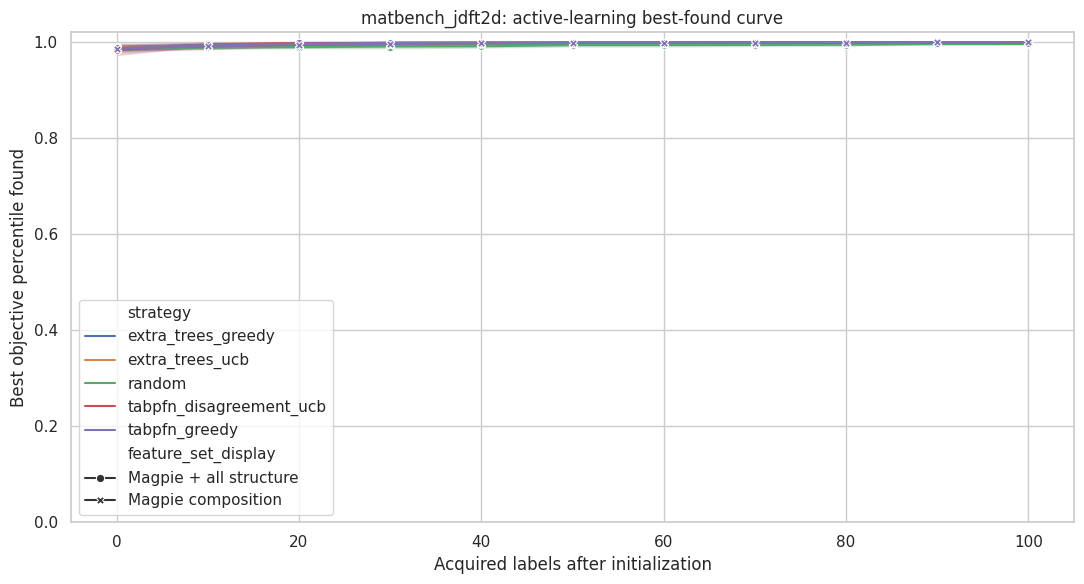

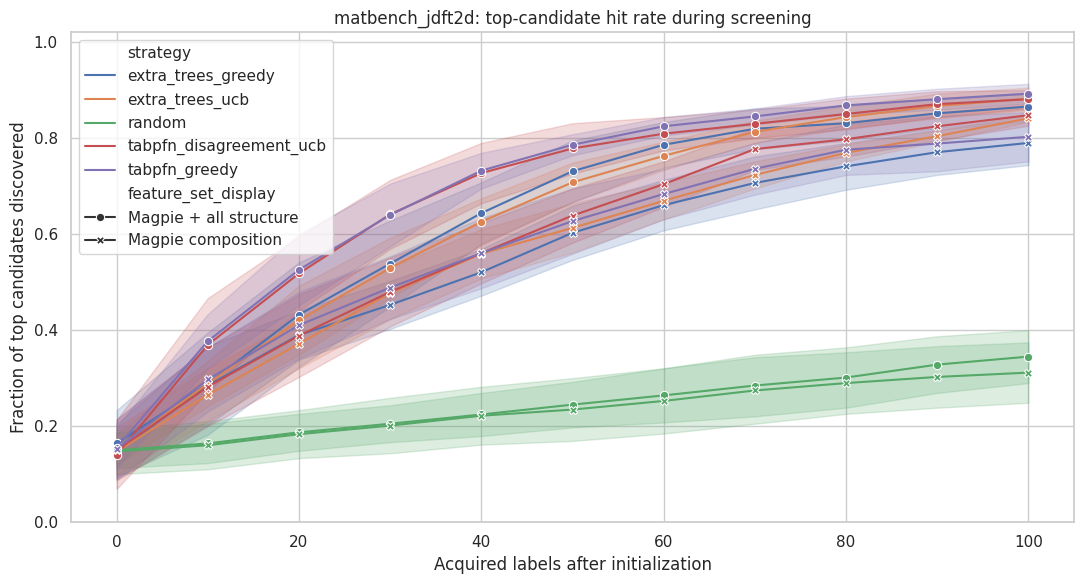

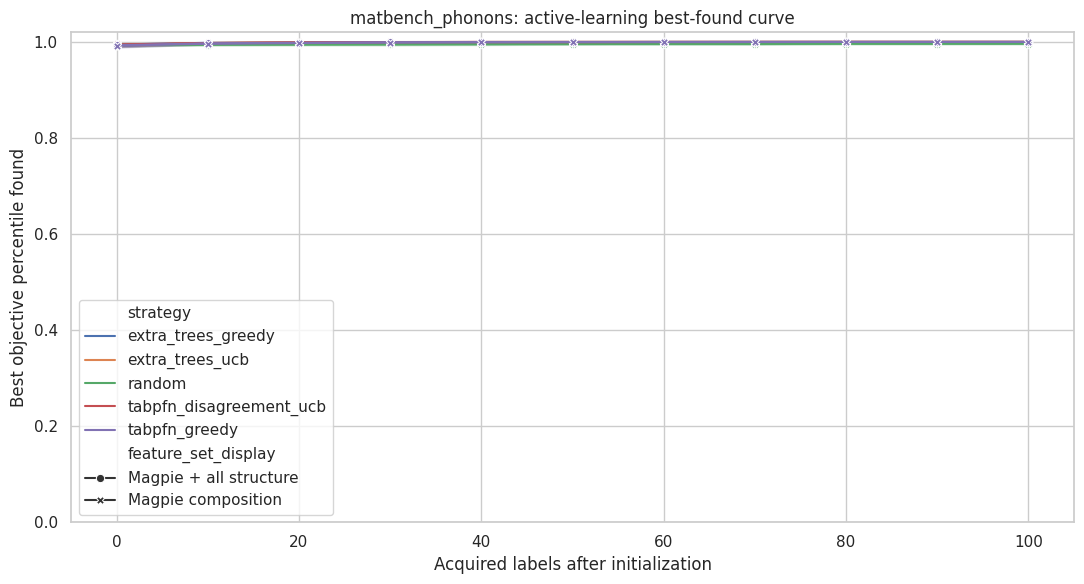

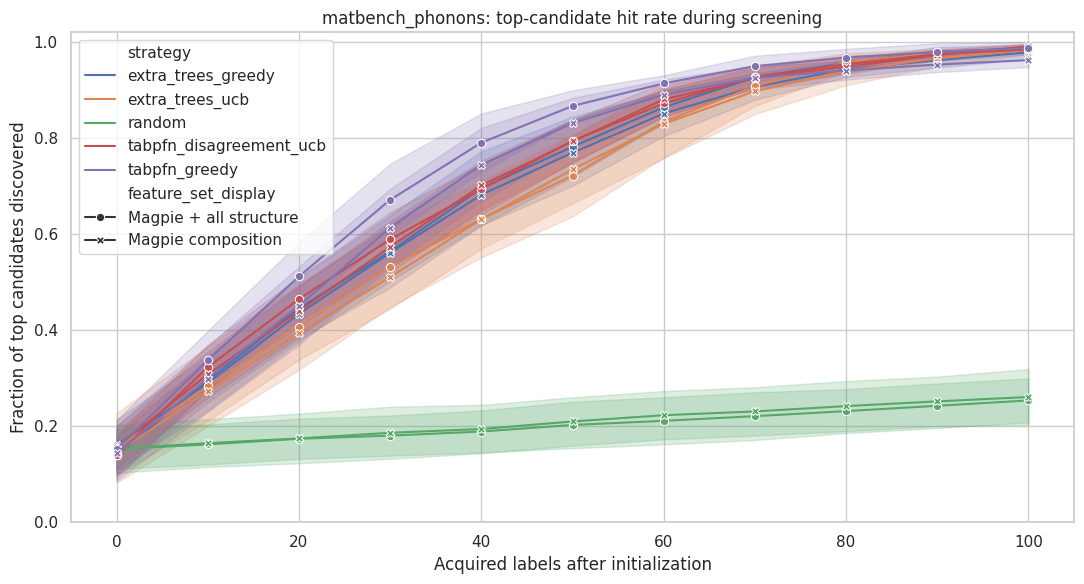

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig_dir = os.path.join(base, "combined_figures")
os.makedirs(fig_dir, exist_ok=True)

sns.set_theme(style="whitegrid")

plot_df = combined_trace.groupby(
    ["task", "feature_set_display", "strategy", "initial_fraction", "acquired_count"],
    dropna=False
).agg(
    best_percentile_mean=("best_objective_percentile_found", "mean"),
    hit_rate_mean=("top_fraction_hit_rate", "mean")
).reset_index()

for task in plot_df["task"].unique():
    task_df = plot_df[plot_df["task"] == task]

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=task_df,
        x="acquired_count",
        y="best_percentile_mean",
        hue="strategy",
        style="feature_set_display",
        markers=True,
        dashes=False,
    )
    plt.title(f"{task}: active-learning best-found curve")
    plt.xlabel("Acquired labels after initialization")
    plt.ylabel("Best objective percentile found")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{task}_combined_best_found_curve.png"), dpi=220)
    plt.show()

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=task_df,
        x="acquired_count",
        y="hit_rate_mean",
        hue="strategy",
        style="feature_set_display",
        markers=True,
        dashes=False,
    )
    plt.title(f"{task}: top-candidate hit rate during screening")
    plt.xlabel("Acquired labels after initialization")
    plt.ylabel("Fraction of top candidates discovered")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{task}_combined_top_hit_curve.png"), dpi=220)
    plt.show()

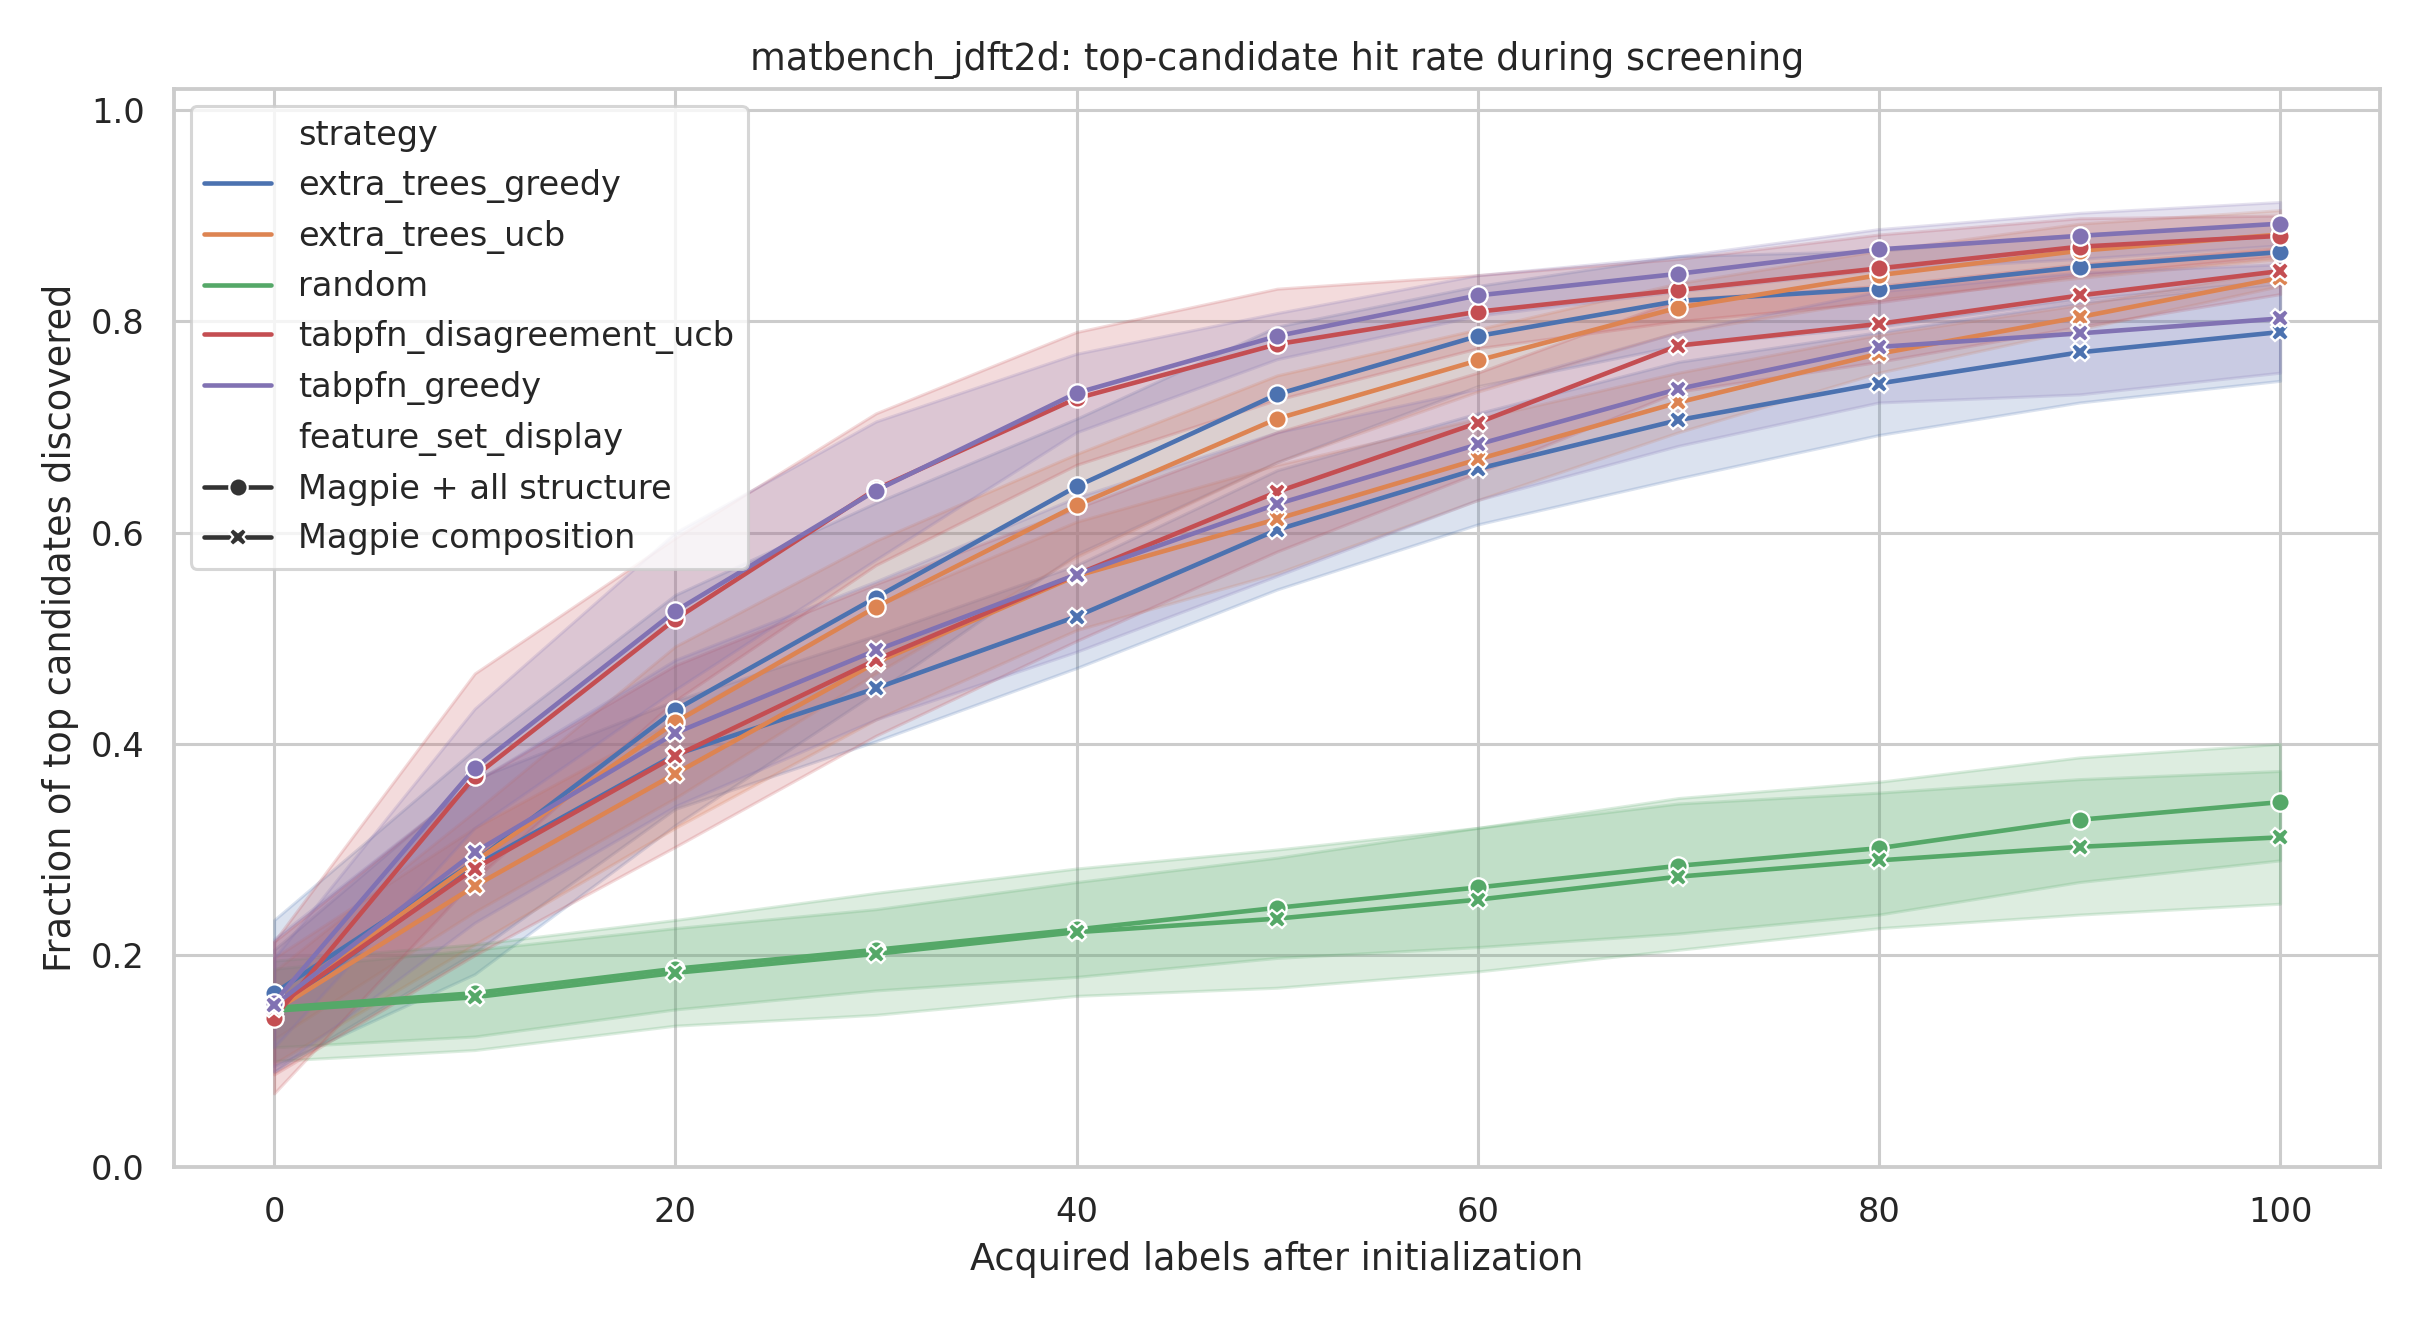

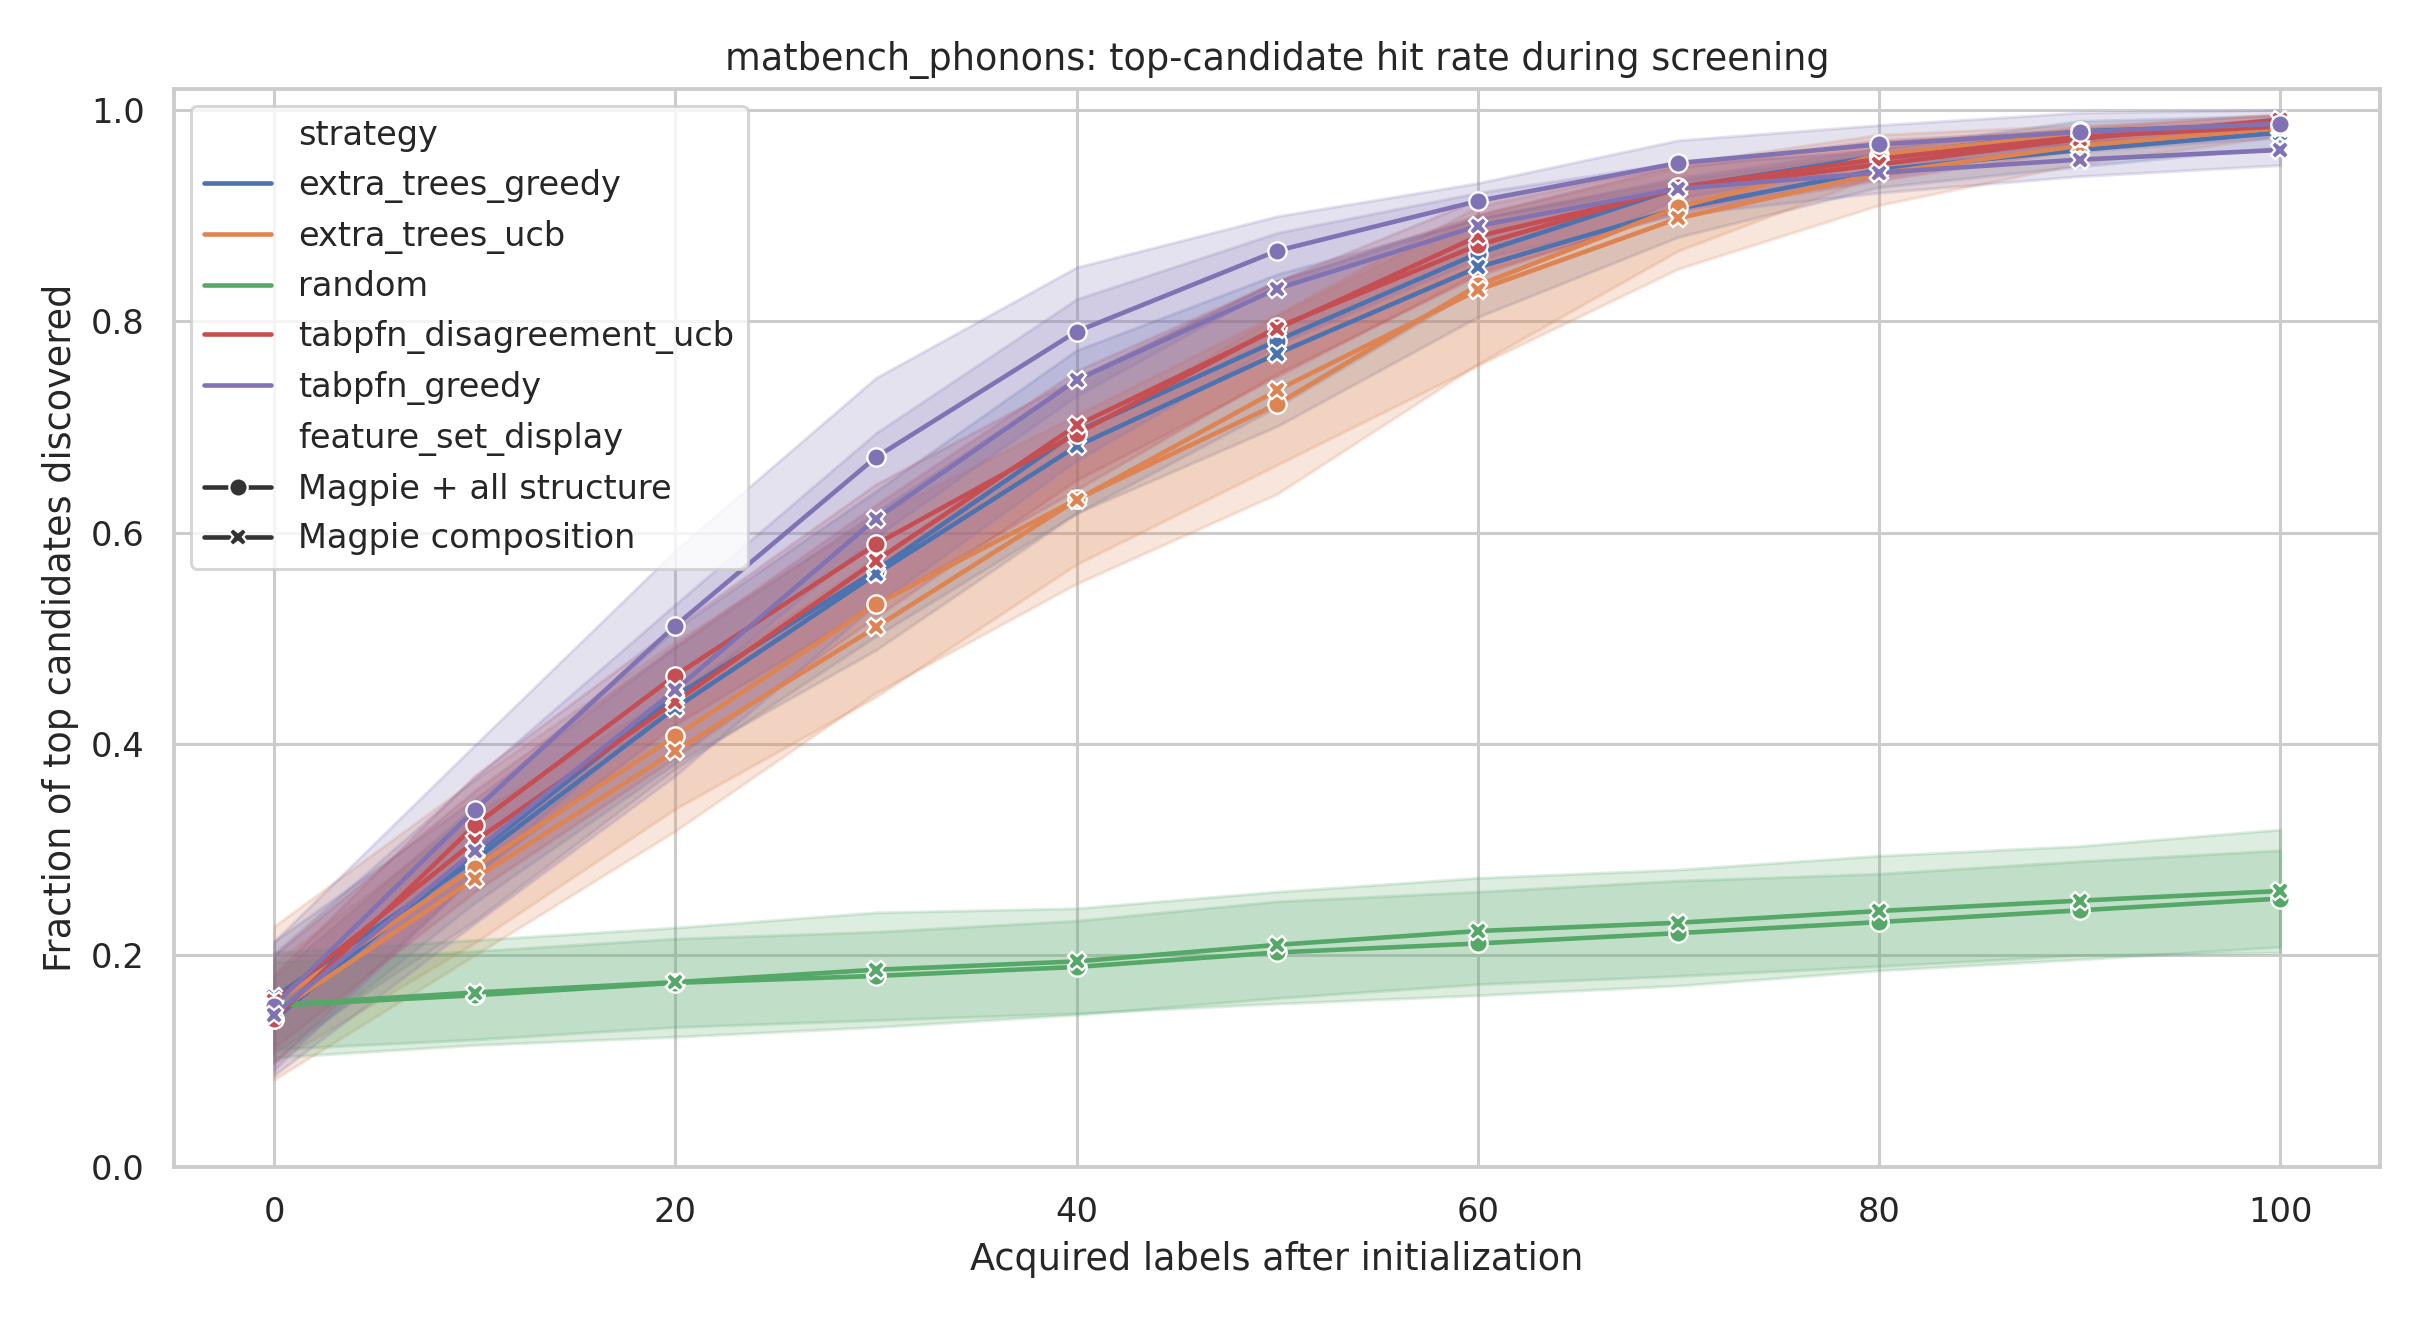

In [14]:
from IPython.display import Image, display
import os

base = "/content/drive/MyDrive/matbench_active_learning_results/combined_figures"

display(Image(os.path.join(base, "matbench_jdft2d_combined_top_hit_curve.png")))
display(Image(os.path.join(base, "matbench_phonons_combined_top_hit_curve.png")))

In [15]:
!python scripts/run_active_learning_screening.py \
  --tasks matbench_jdft2d matbench_phonons \
  --feature-sets magpie magpie_structure_all \
  --strategies random extra_trees_greedy tabpfn_greedy tabpfn_disagreement_ucb \
  --initial-fractions 0.05 \
  --top-fraction 0.01 \
  --folds 0 1 \
  --max-acquisitions 100 \
  --acquisition-batch-size 10 \
  --repeats 1 \
  --device cuda

2026-06-06 20:44:22 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-06 20:44:22 INFO     Loading dataset 'matbench_jdft2d'...
2026-06-06 20:44:22 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | random | fold 0 | init 5% | repeat 0
matbench_jdft2d | magpie | extra_trees_greedy | fold 0 | init 5% | repeat 0
matbench_jdft2d | magpie | tabpfn_greedy | fold 0 | init 5% | repeat 0
matbench_jdft2d | magpie | tabpfn_disagreement_ucb | fold 0 | init 5% | repeat 0
matbench_jdft2d | magpie | random | fold 1 | init 5% | repeat 0
matbench_jdft2d | magpie | extra_trees_greedy | fold 1 | init 5% | repeat 0
matbench_jdft2d | magpie | tabpfn_greedy | fold 1 | init 5% | repeat 0
matbench_jdft2d | magpie | tabpfn_disagreement_ucb | fold 1 | init 5% | repeat 0
Building features: matbench_jdft2d | magpie_structure_all
matbench_jdft2d | magpie_structure_all | random | fold 0 | init 5% | repeat 0
matben

Latest run: results/active_learning_screening/gpu_20260606_204419_utc
Figures:
['active_learning_final_regret_ranking.png', 'active_learning_best_found_curve.png', 'active_learning_top_fraction_hit_curve.png']


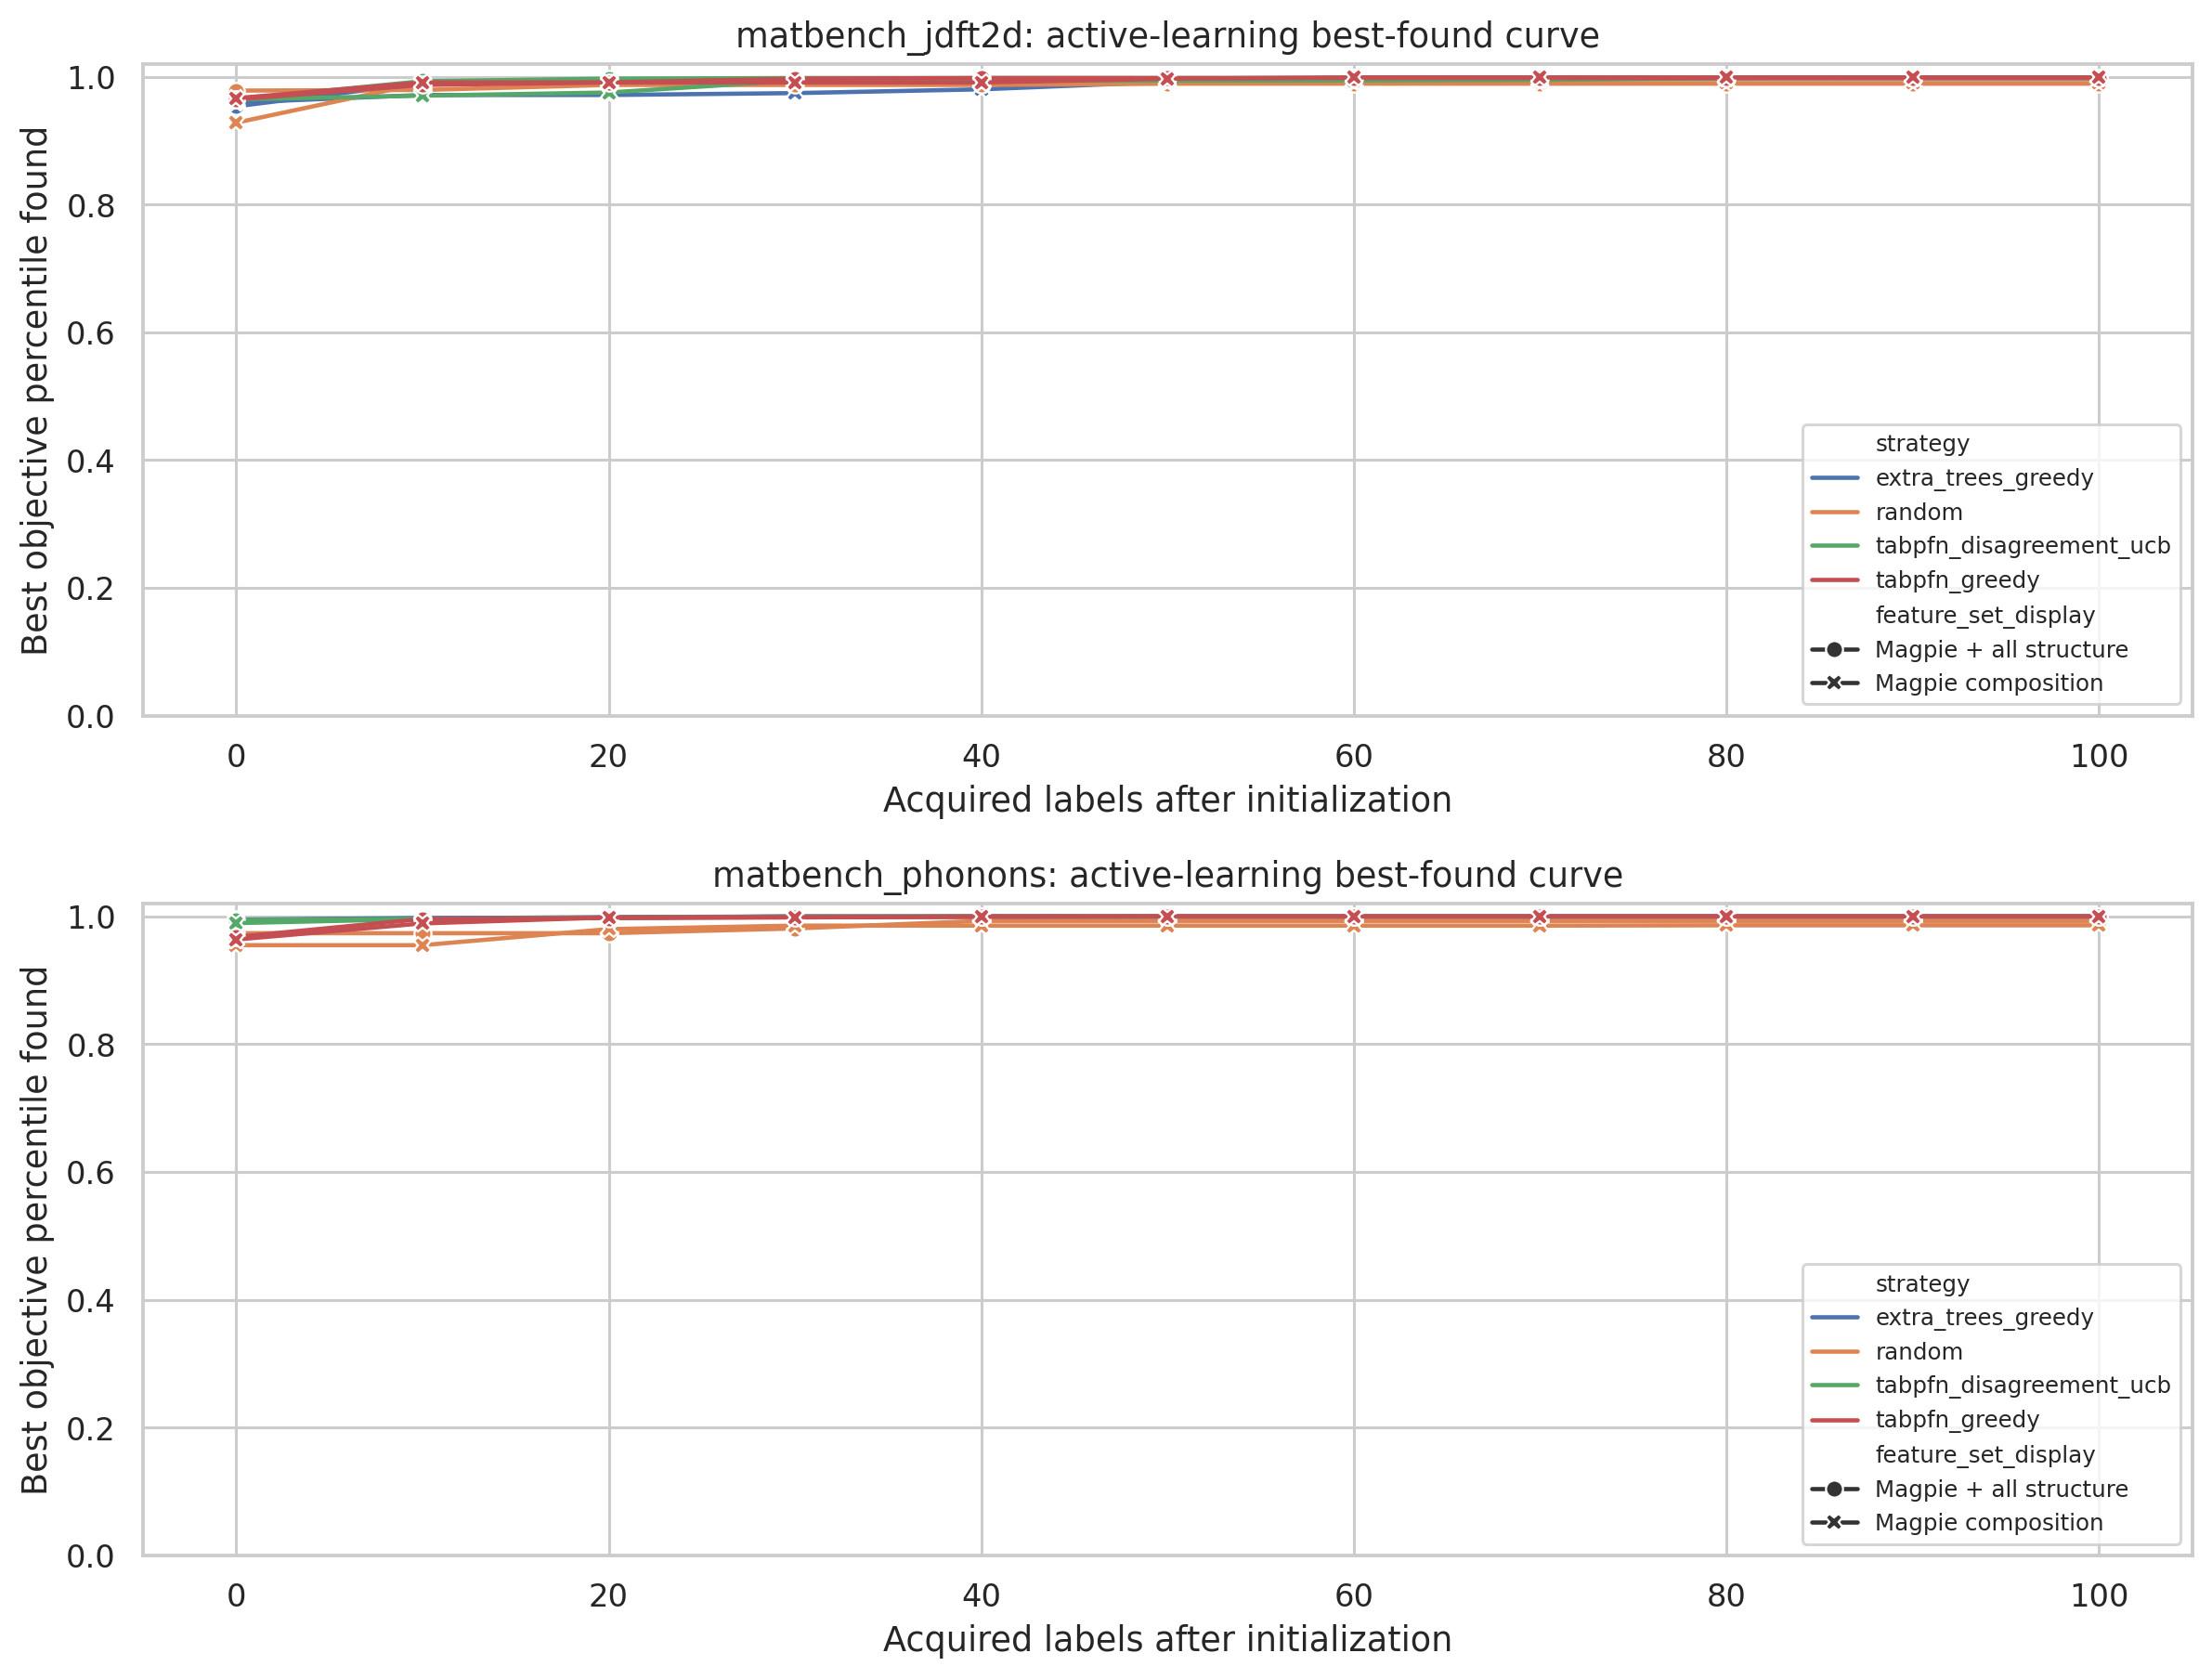

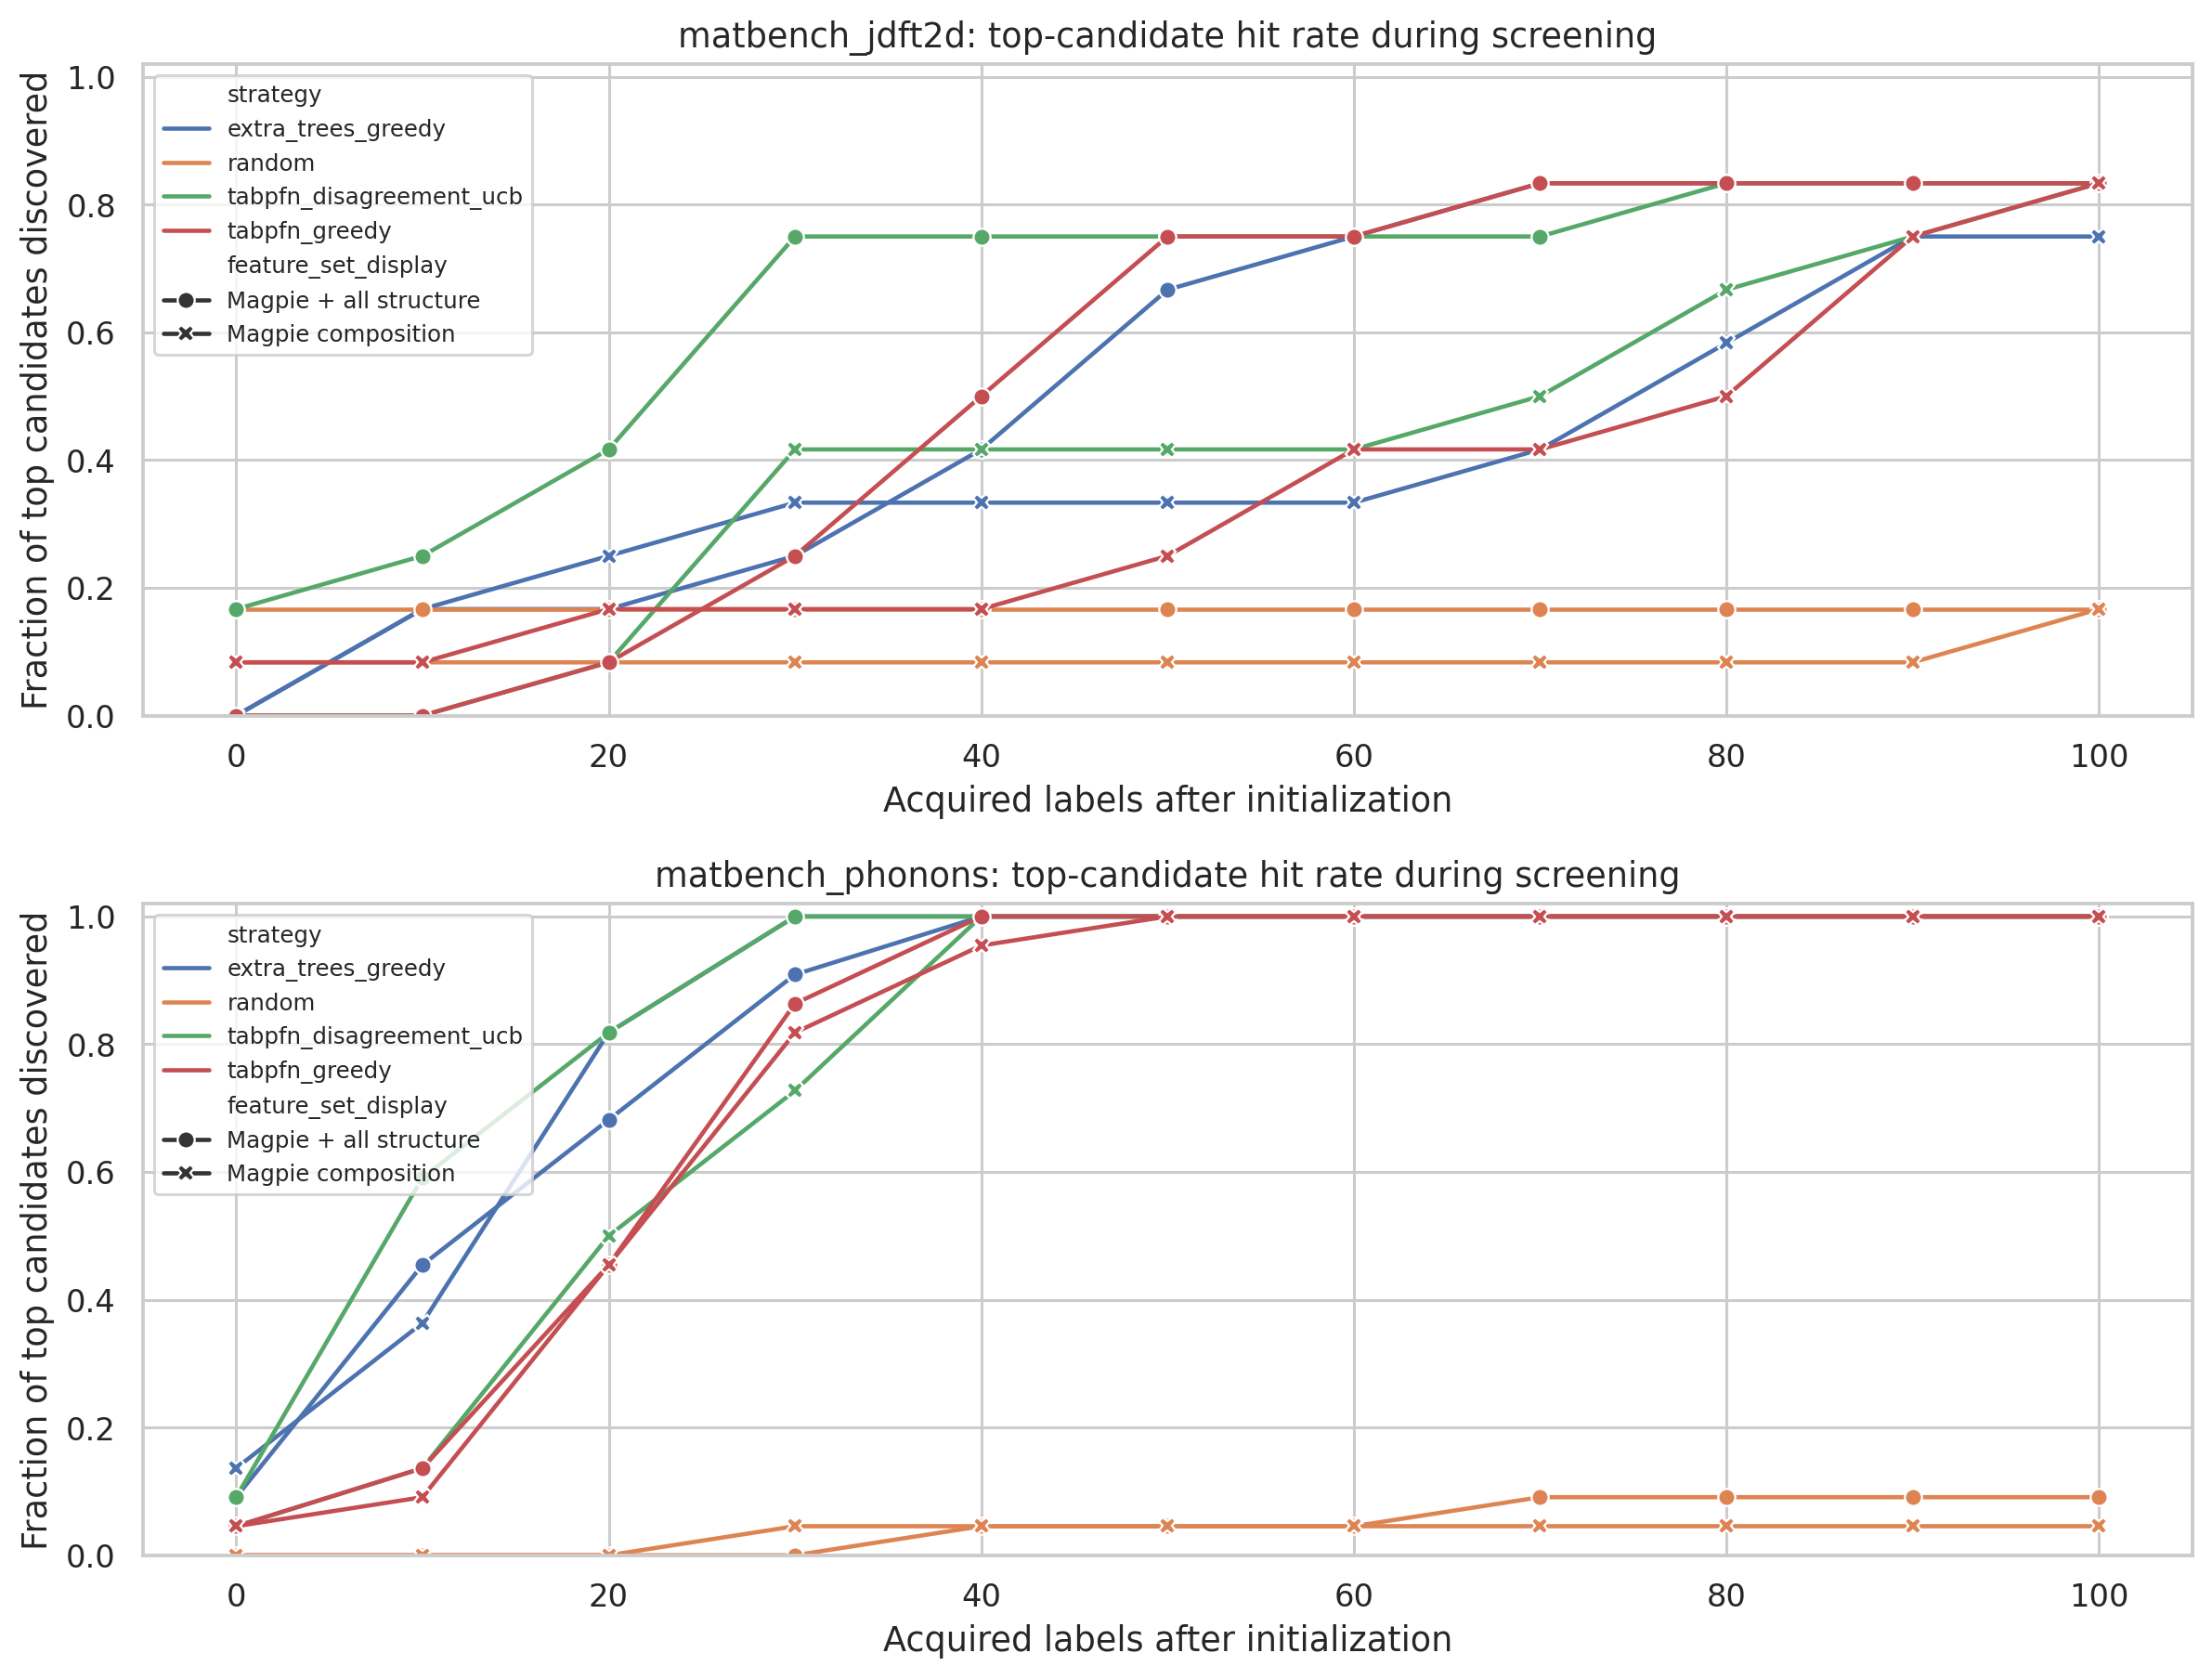

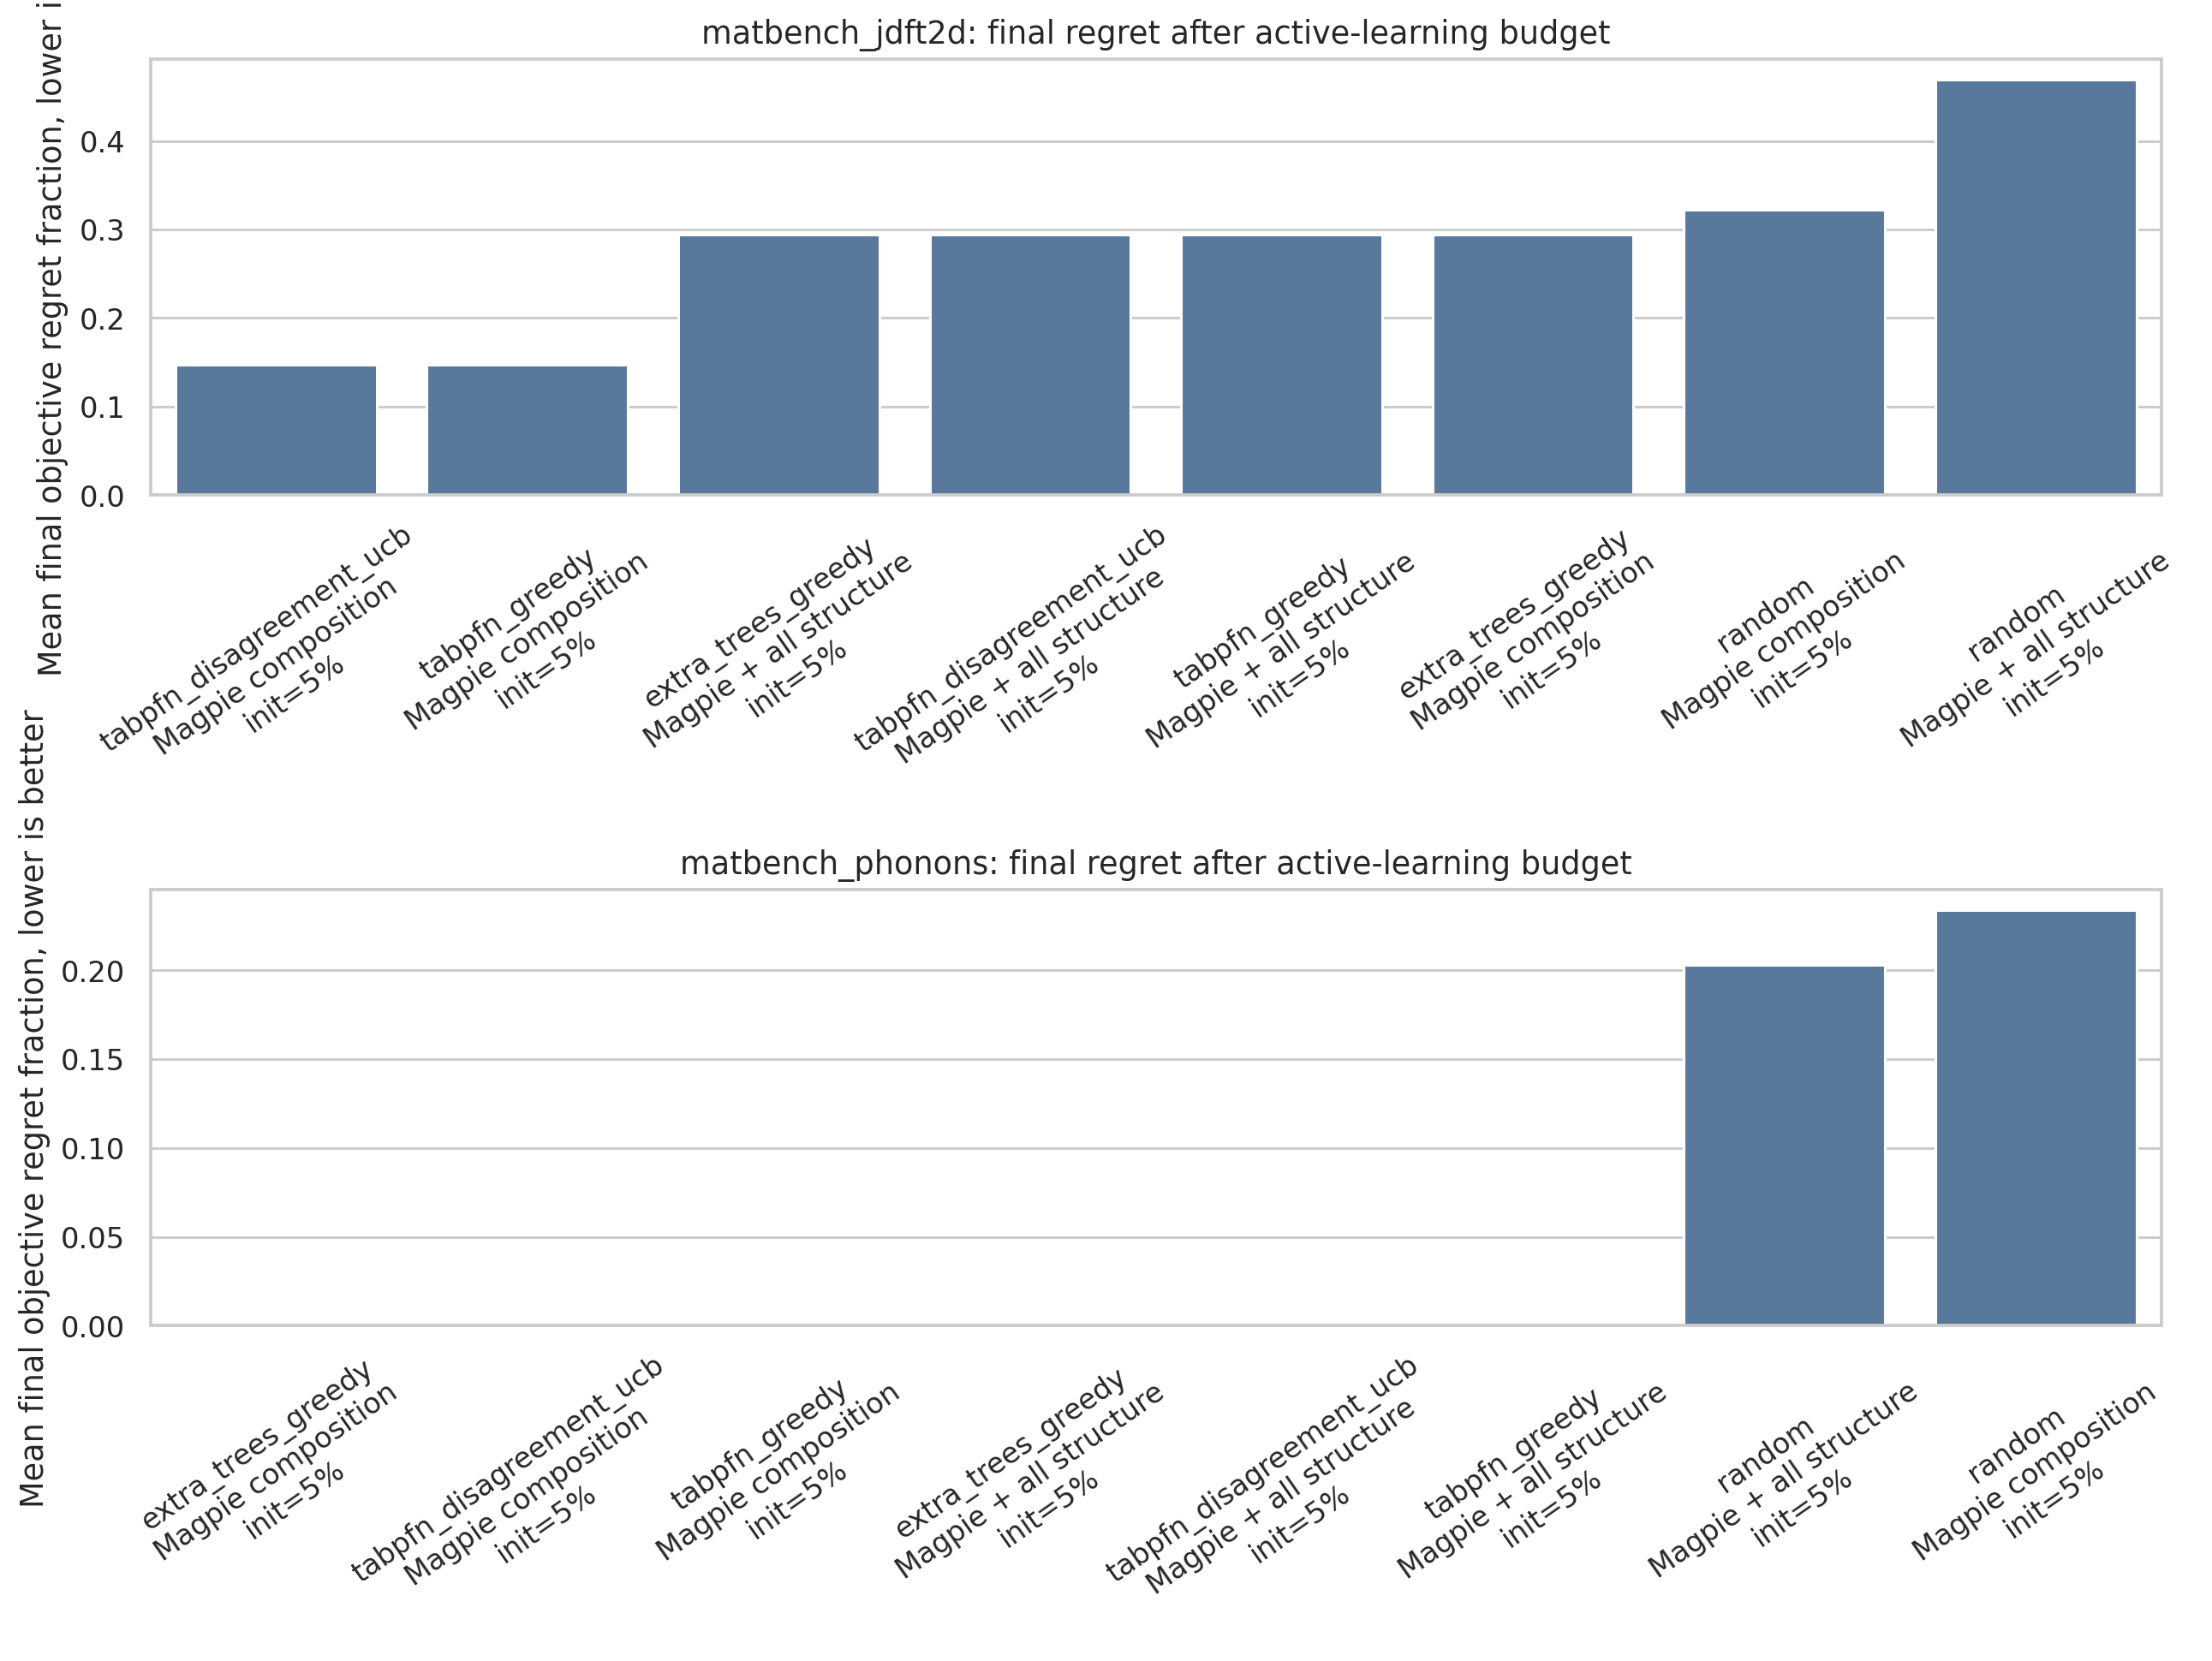

,task,unit,feature_set,feature_set_display,strategy,initial_fraction,n_runs,found_global_best_rate,acquisitions_to_global_best_mean,acquisitions_to_global_best_median,first_top_fraction_acquisitions_mean,final_objective_gap_mean,final_objective_regret_fraction_mean,final_best_objective_percentile_mean,final_top_fraction_hit_rate_mean,final_top_fraction_hit_count_mean,fit_seconds_sum,predict_seconds_sum
0,matbench_jdft2d,meV/atom,magpie,Magpie composition,tabpfn_disagreement_ucb,0.05,2,0.5,70.0,70.0,25.0,236.276643,0.147301,0.999016,0.833333,5.0,22.876527,54.004779
1,matbench_jdft2d,meV/atom,magpie,Magpie composition,tabpfn_greedy,0.05,2,0.5,0.0,0.0,25.0,236.276643,0.147301,0.999016,0.833333,5.0,14.651010,52.425633
2,matbench_jdft2d,meV/atom,magpie_structure_all,Magpie + all structure,extra_trees_greedy,0.05,2,0.0,NaN,NaN,10.0,472.553286,0.294602,0.998033,0.833333,5.0,9.356206,2.423233
3,matbench_jdft2d,meV/atom,magpie_structure_all,Magpie + all structure,tabpfn_disagreement_ucb,0.05,2,0.0,NaN,NaN,10.0,472.553286,0.294602,0.998033,0.833333,5.0,23.219086,55.053698
4,matbench_jdft2d,meV/atom,magpie_structure_all,Magpie + all structure,tabpfn_greedy,0.05,2,0.0,NaN,NaN,25.0,472.553286,0.294602,0.998033,0.833333,5.0,13.792461,52.405216
5,matbench_jdft2d,meV/atom,magpie,Magpie composition,extra_trees_greedy,0.05,2,0.0,NaN,NaN,40.0,472.553286,0.294602,0.998033,0.750000,4.5,9.133288,2.378636
6,matbench_jdft2d,meV/atom,magpie,Magpie composition,random,0.05,2,0.5,0.0,0.0,0.0,516.190543,0.321807,0.990157,0.166667,1.0,0.000000,0.000000
7,matbench_jdft2d,meV/atom,magpie_structure_all,Magpie + all structure,random,0.05,2,0.0,NaN,NaN,0.0,752.467186,0.469108,0.989193,0.166667,1.0,0.000000,0.000000
8,matbench_phonons,cm^-1,magpie,Magpie composition,extra_trees_greedy,0.05,2,1.0,25.0,25.0,0.0,0.000000,0.000000,1.000000,1.000000,11.0,9.353532,3.095331
9,matbench_phonons,cm^-1,magpie,Magpie composition,tabpfn_disagreement_ucb,0.05,2,1.0,30.0,30.0,5.0,0.000000,0.000000,1.000000,1.000000,11.0,23.211178,104.941910


# Active-Learning Screening Summary

This extension is inspired by ICAL-style pool-based active learning, but it is a retrospective Matbench diagnostic rather than a full ICAL reproduction.

The official Matbench train fold is split into a small labeled set and an unlabeled candidate pool. Each strategy sequentially acquires labels from that pool, and success is measured by discovery efficiency rather than MAE.

## Configuration

- Objective direction: `maximize`.
- Initial labeled fractions: `5%`.
- Top-candidate definition: top `1%` by objective value.
- Acquisition batch size: `10`.
- Maximum acquisitions: `100`.
- Strategies: `random, extra_trees_greedy, tabpfn_greedy, tabpfn_disagreement_ucb`.

## Best Conditions By Final Regret

- `matbench_jdft2d` init=5%: best condition is `tabpfn_disagreement_ucb` with `Magpie composition`, mean final regret=0.1473, mean top-candidate hit rate=0.833.
- `matbench_phonons` init=5%: best condition is `extra_trees_greedy` with `Magpie composition`

In [16]:
from IPython.display import Image, display
import glob, os
import pandas as pd

latest = sorted(glob.glob("results/active_learning_screening/*"))[-1]
print("Latest run:", latest)

fig_dir = os.path.join(latest, "figures")
table_dir = os.path.join(latest, "tables")

print("Figures:")
print(os.listdir(fig_dir))

display(Image(os.path.join(fig_dir, "active_learning_best_found_curve.png")))
display(Image(os.path.join(fig_dir, "active_learning_top_fraction_hit_curve.png")))
display(Image(os.path.join(fig_dir, "active_learning_final_regret_ranking.png")))

summary_path = os.path.join(table_dir, "active_learning_aggregate_summary.csv")
summary = pd.read_csv(summary_path)

display(summary.sort_values(
    ["task", "initial_fraction", "final_objective_regret_fraction_mean", "final_top_fraction_hit_rate_mean"],
    ascending=[True, True, True, False]
).head(40))

!cat {latest}/tables/active_learning_screening_summary.md

Latest Drive run: /content/drive/MyDrive/matbench_active_learning_results/gpu_20260606_183904_utc
Figures:
['active_learning_best_found_curve.png', 'active_learning_top_fraction_hit_curve.png', 'active_learning_final_regret_ranking.png']


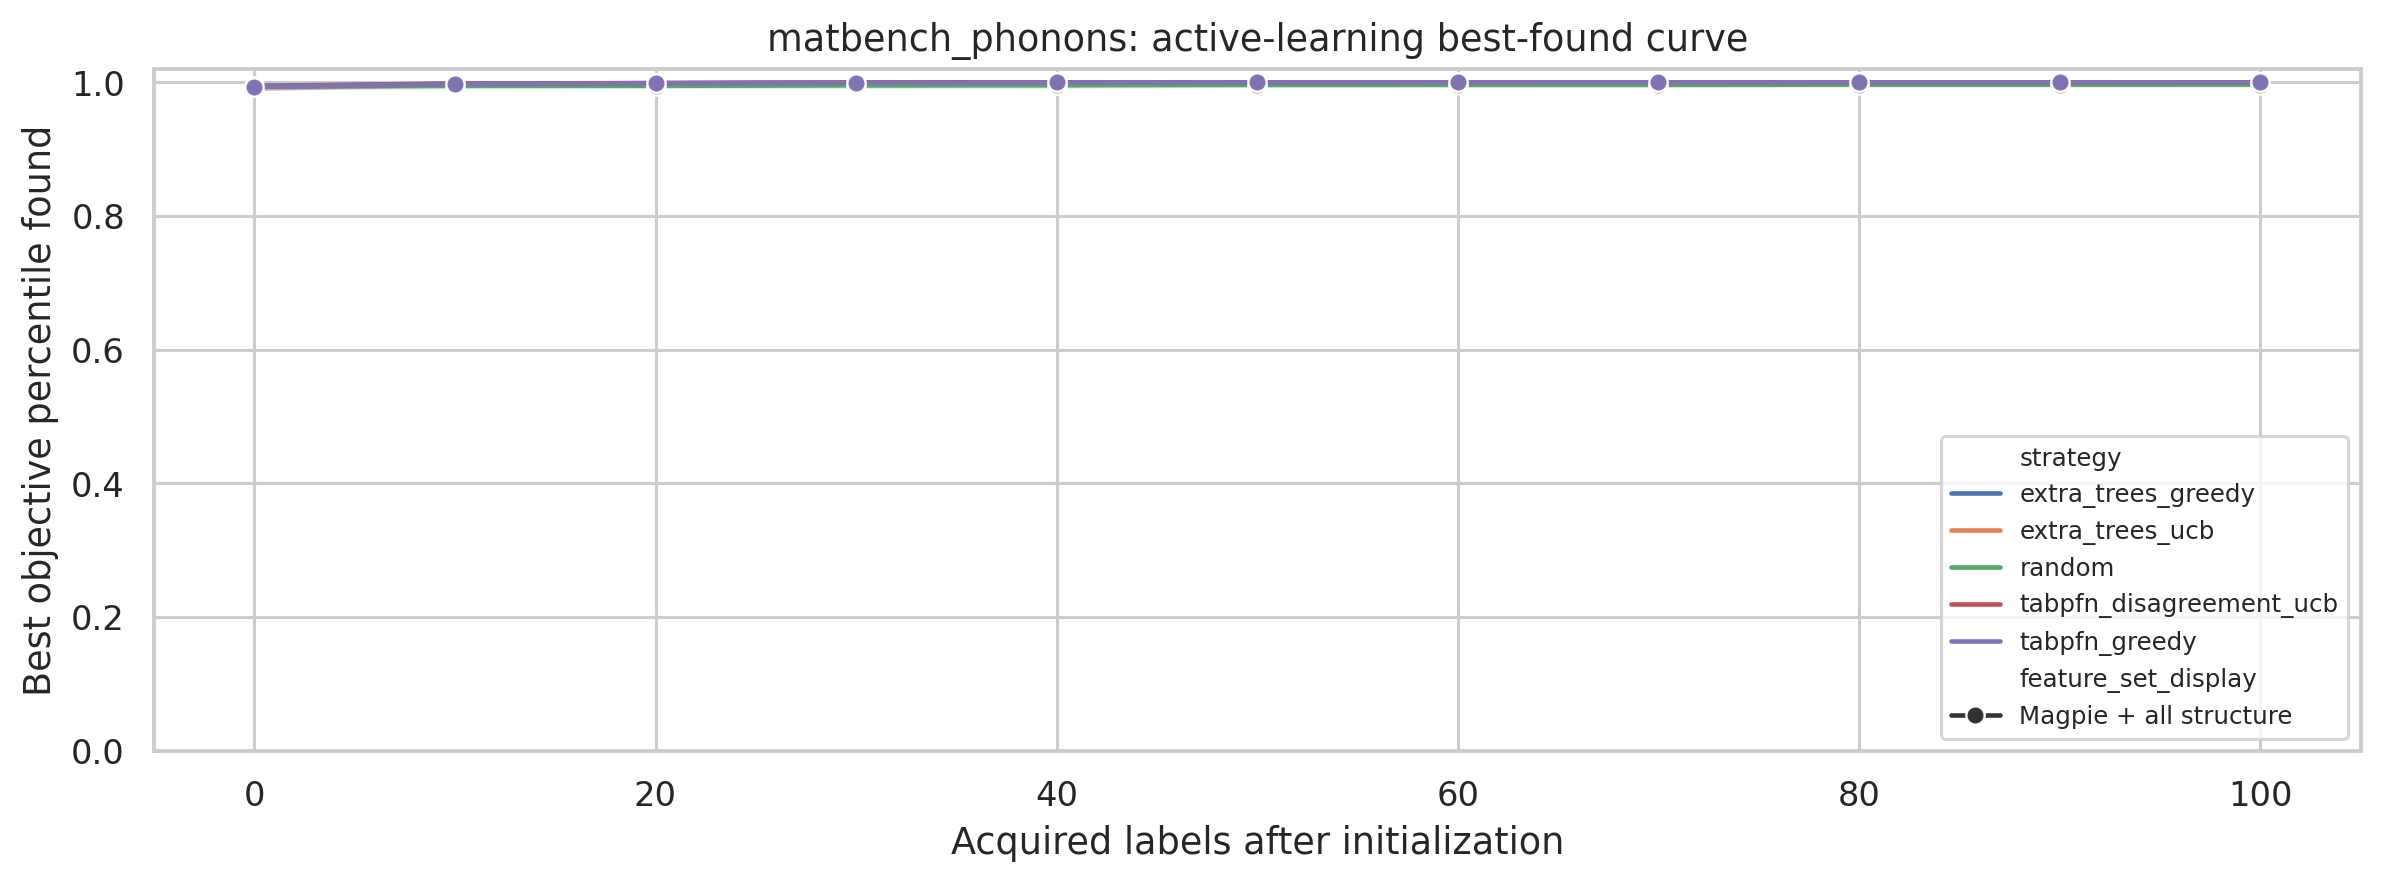

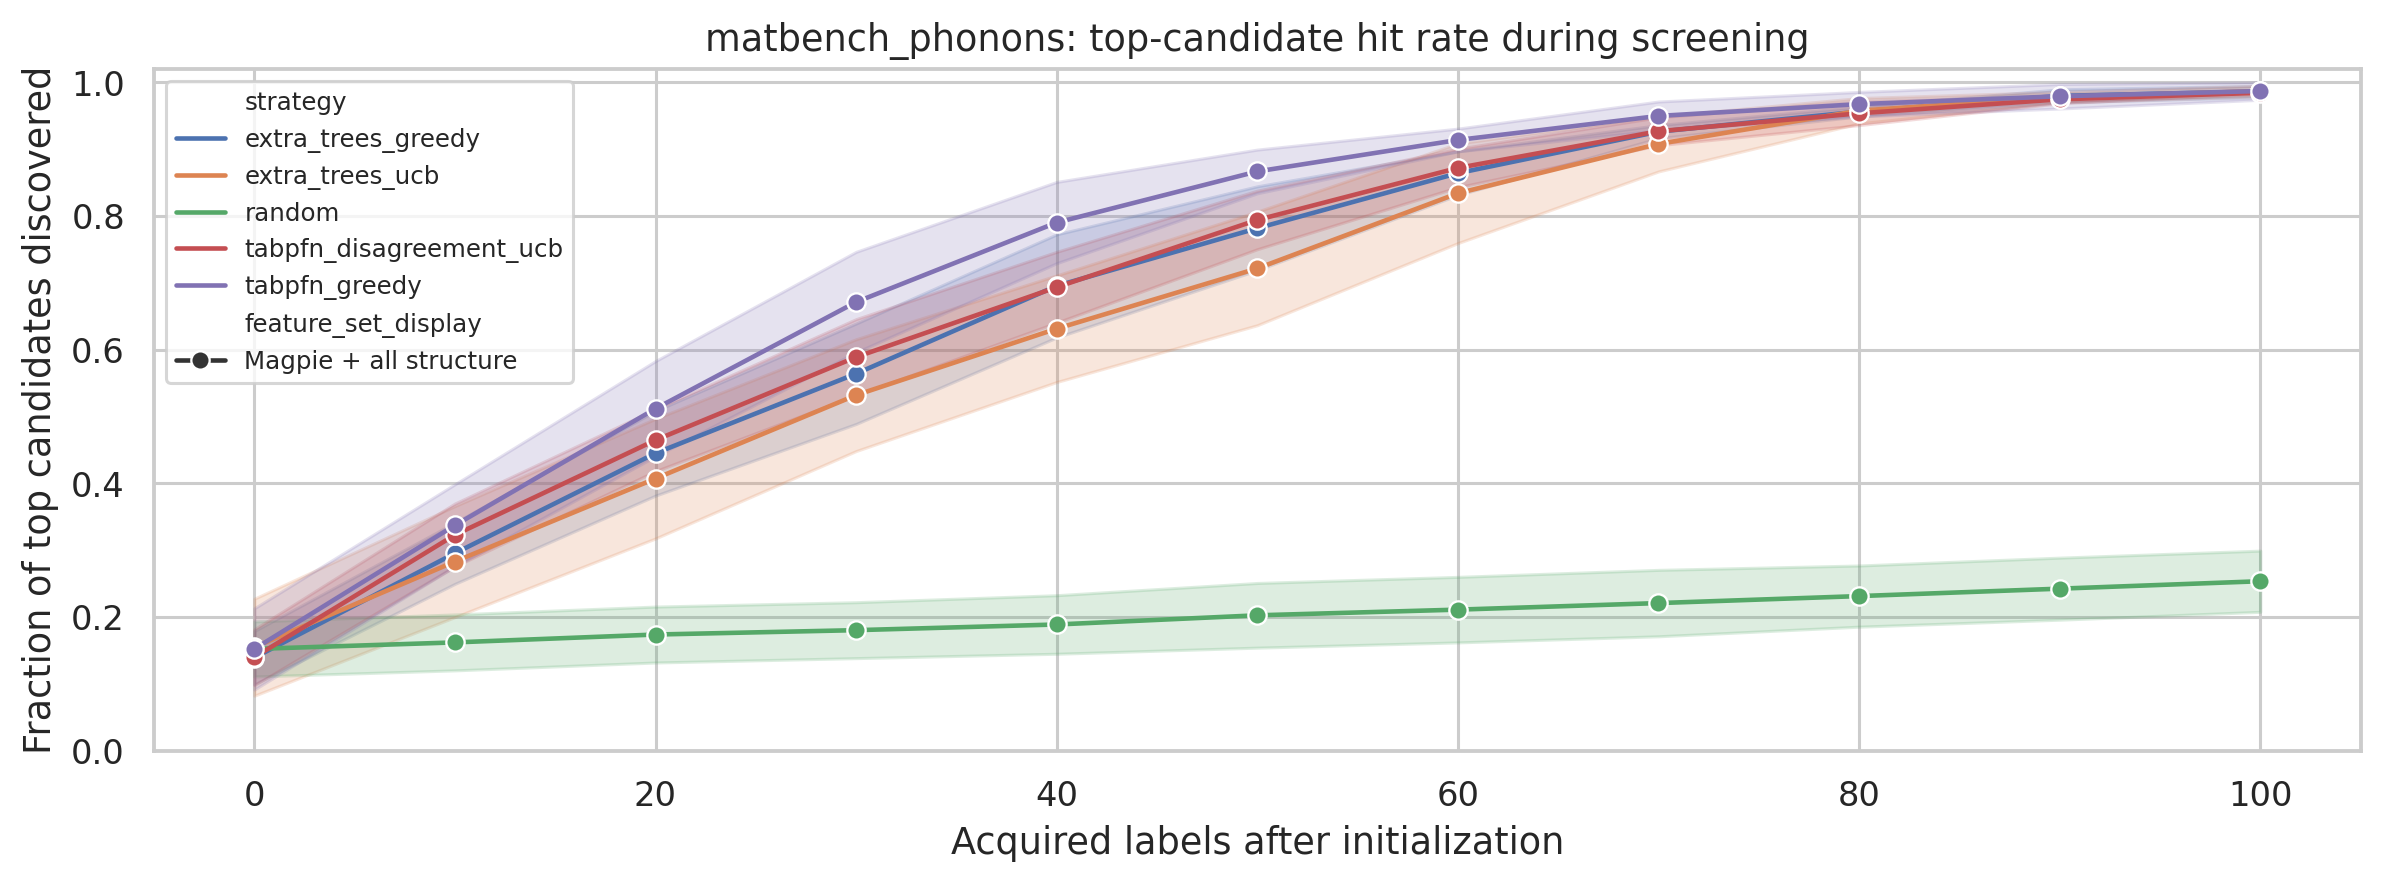

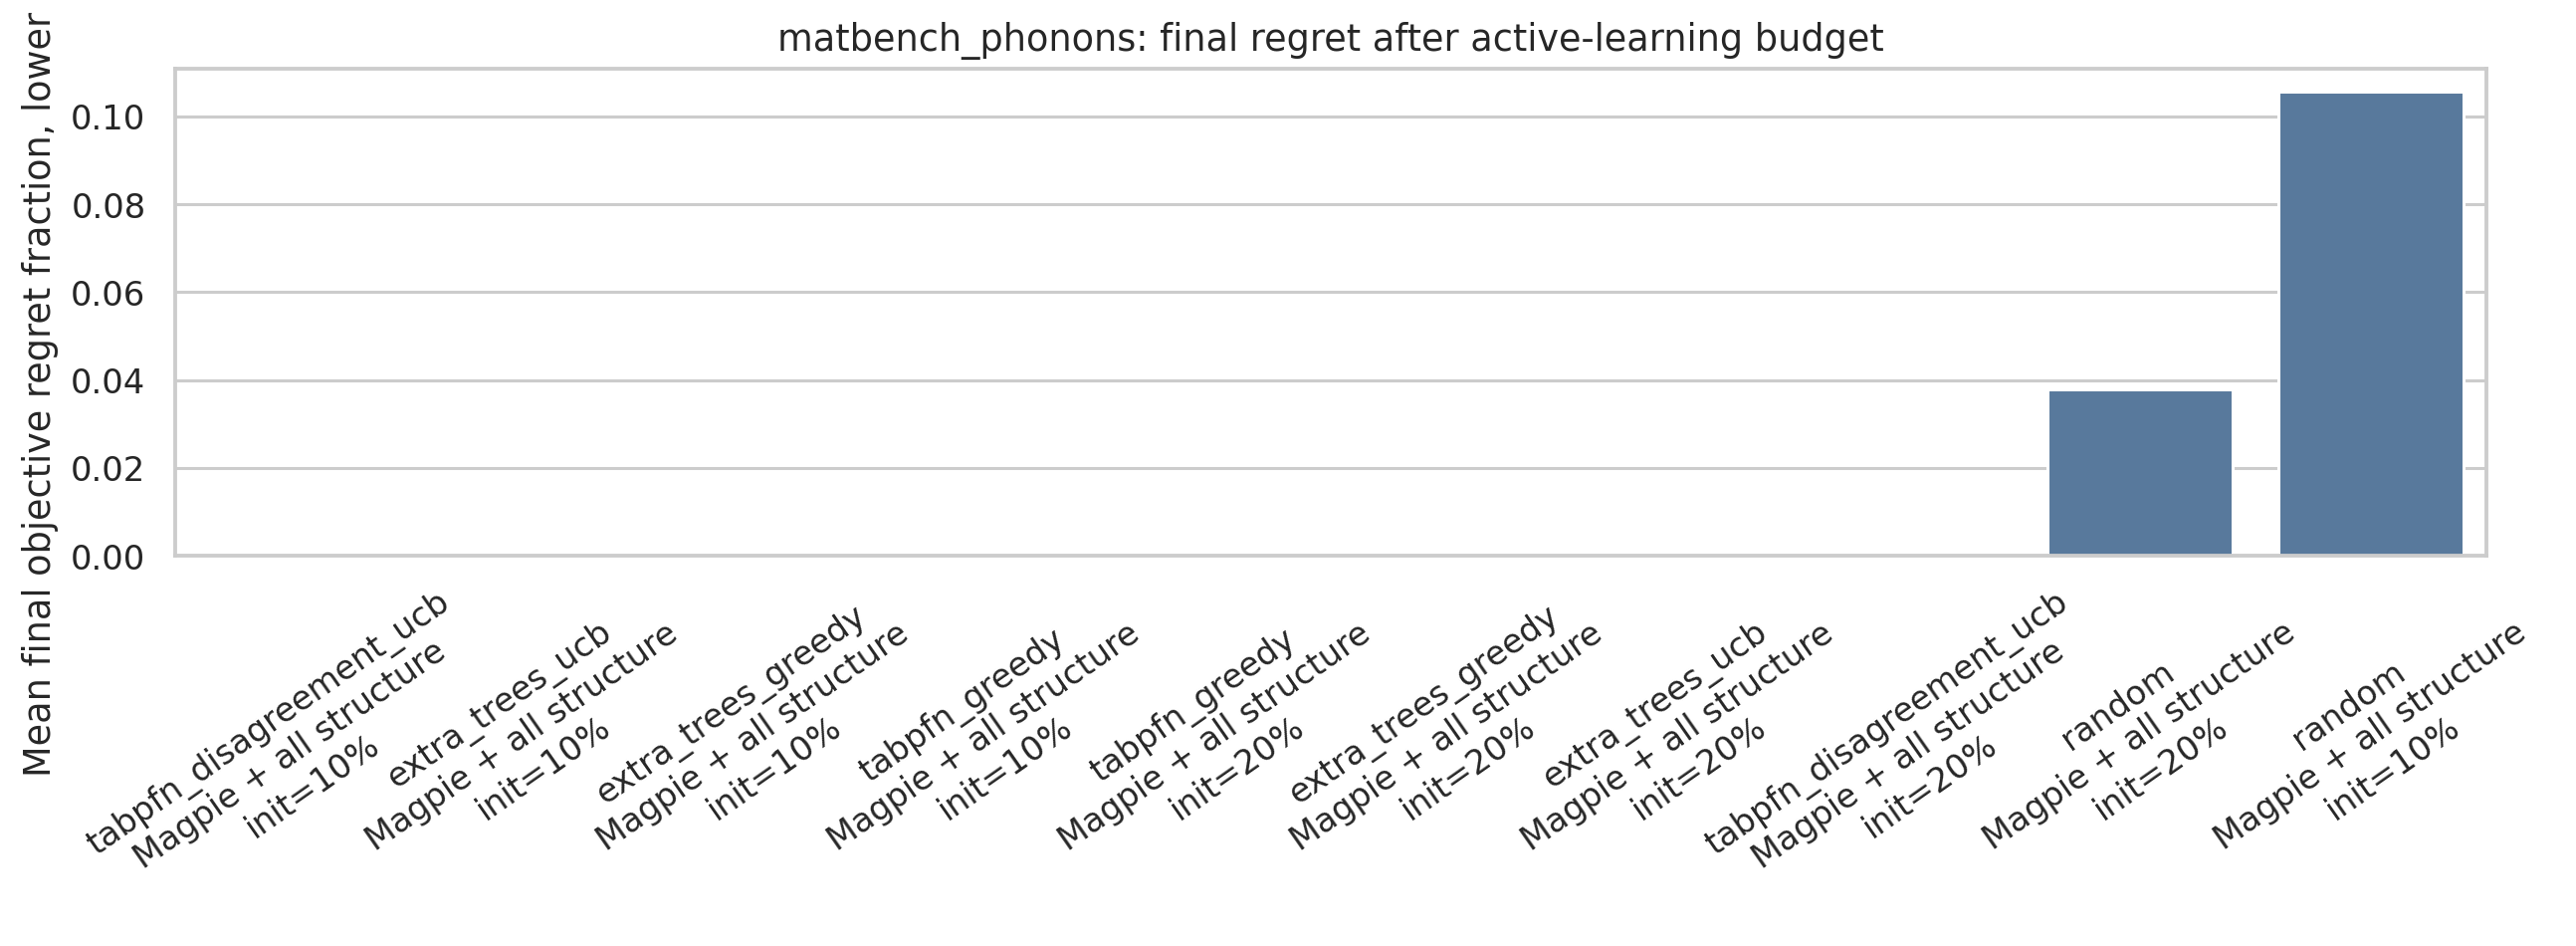

,task,unit,feature_set,feature_set_display,strategy,initial_fraction,n_runs,found_global_best_rate,acquisitions_to_global_best_mean,acquisitions_to_global_best_median,first_top_fraction_acquisitions_mean,final_objective_gap_mean,final_objective_regret_fraction_mean,final_best_objective_percentile_mean,final_top_fraction_hit_rate_mean,final_top_fraction_hit_count_mean,fit_seconds_sum,predict_seconds_sum
0,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,tabpfn_disagreement_ucb,0.1,15,1.000000,24.000000,30.0,0.0,0.000000,0.000000,1.000000,0.983007,50.133333,189.626439,776.345450
1,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,extra_trees_ucb,0.1,15,1.000000,26.000000,20.0,0.0,0.000000,0.000000,1.000000,0.979085,49.933333,78.183375,22.045173
2,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,extra_trees_greedy,0.1,15,1.000000,19.333333,20.0,0.0,0.000000,0.000000,1.000000,0.977778,49.866667,77.457530,22.017151
3,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,tabpfn_greedy,0.1,15,1.000000,36.000000,40.0,0.0,0.000000,0.000000,1.000000,0.973856,49.666667,109.843977,754.667577
4,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,random,0.1,15,0.133333,5.000000,5.0,0.0,384.621376,0.105576,0.995125,0.207843,10.600000,0.000000,0.000000
5,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,tabpfn_greedy,0.2,15,1.000000,34.000000,40.0,0.0,0.000000,0.000000,1.000000,1.000000,51.000000,110.204397,689.741716
6,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,extra_trees_greedy,0.2,15,1.000000,14.666667,10.0,0.0,0.000000,0.000000,1.000000,0.994771,50.733333,95.848063,22.511175
7,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,extra_trees_ucb,0.2,15,1.000000,15.333333,20.0,0.0,0.000000,0.000000,1.000000,0.994771,50.733333,95.698682,22.275381
8,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,tabpfn_disagreement_ucb,0.2,15,1.000000,16.666667,10.0,0.0,0.000000,0.000000,1.000000,0.985621,50.266667,207.377614,711.111173
9,matbench_phonons,cm^-1,magpie_structure_all,Magpie + all structure,random,0.2,15,0.466667,11.428571,0.0,0.0,138.435413,0.038012,0.998024,0.299346,15.266667,0.000000,0.000000


# Active-Learning Screening Summary

This extension is inspired by ICAL-style pool-based active learning, but it is a retrospective Matbench diagnostic rather than a full ICAL reproduction.

The official Matbench train fold is split into a small labeled set and an unlabeled candidate pool. Each strategy sequentially acquires labels from that pool, and success is measured by discovery efficiency rather than MAE.

## Configuration

- Objective direction: `maximize`.
- Initial labeled fractions: `10%, 20%`.
- Top-candidate definition: top `5%` by objective value.
- Acquisition batch size: `10`.
- Maximum acquisitions: `100`.
- Strategies: `random, extra_trees_greedy, extra_trees_ucb, tabpfn_greedy, tabpfn_disagreement_ucb`.

## Best Conditions By Final Regret

- `matbench_phonons` init=10%: best condition is `tabpfn_disagreement_ucb` with `Magpie + all structure`, mean final regret=0, mean top-candidate hit rate=0.983.
- `matbench_phonons` init=20%: best condition is `tabpfn_greedy` with 

In [17]:
from IPython.display import Image, display
import glob, os
import pandas as pd

base = "/content/drive/MyDrive/matbench_active_learning_results"
run_dirs = sorted(glob.glob(os.path.join(base, "gpu_*")))
latest = run_dirs[-1]

print("Latest Drive run:", latest)

fig_dir = os.path.join(latest, "figures")
table_dir = os.path.join(latest, "tables")

print("Figures:")
print(os.listdir(fig_dir))

display(Image(os.path.join(fig_dir, "active_learning_best_found_curve.png")))
display(Image(os.path.join(fig_dir, "active_learning_top_fraction_hit_curve.png")))
display(Image(os.path.join(fig_dir, "active_learning_final_regret_ranking.png")))

summary = pd.read_csv(os.path.join(table_dir, "active_learning_aggregate_summary.csv"))

display(summary.sort_values(
    ["task", "initial_fraction", "final_objective_regret_fraction_mean", "final_top_fraction_hit_rate_mean"],
    ascending=[True, True, True, False]
).head(40))

!cat {latest}/tables/active_learning_screening_summary.md

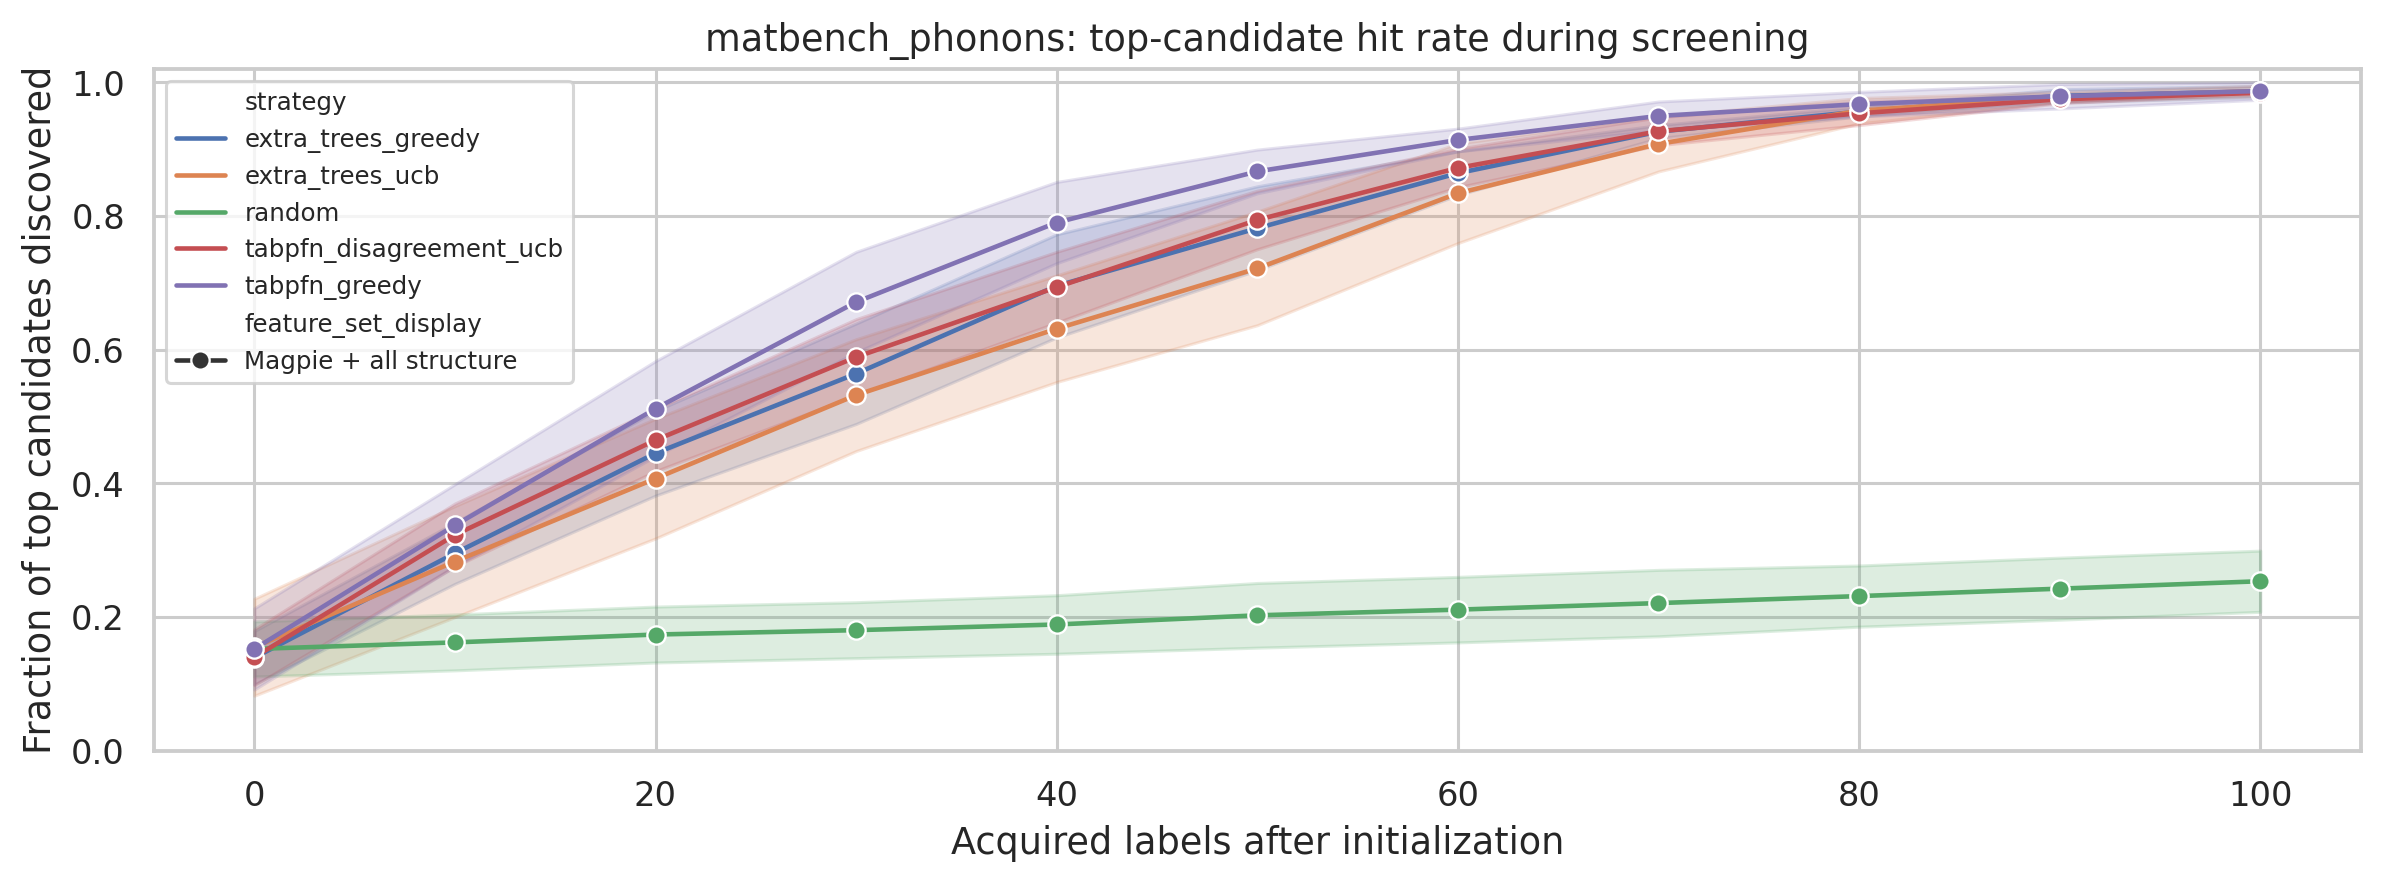

In [21]:
display(Image(os.path.join(fig_dir, "active_learning_top_fraction_hit_curve.png")))